In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Core libraries for handling the data
import numpy as np
import pandas as pd

# Libraries for plotting
import seaborn as sns
import matplotlib.pyplot as plt

import sklearn

RANDOM_STATE = 42

# Making the plots a bit easier to read
sns.set_theme(style="whitegrid")
%matplotlib inline

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)

numpy: 2.4.1
pandas: 3.0.5
sklearn: 1.8.0


In [3]:

df = pd.read_csv('Cars.csv')

df_raw = df.copy()

print("The dataset has", df.shape[0], "rows and", df.shape[1], "columns")

The dataset has 8128 rows and 13 columns


In [4]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


In [6]:
# These four columns look like numbers to a human but pandas reads them as text
# because the unit is written inside the value. I will have to strip the units later.
df[['mileage', 'engine', 'max_power', 'torque']].head()

,mileage,engine,max_power,torque
0,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
1,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm
2,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)"
3,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm
4,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)"


In [7]:
# Counting the missing values per column and turning it into a percentage
# so I can judge whether dropping or filling is the better choice.
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().sum() / len(df) * 100).round(2)
})
missing[missing['missing_count'] > 0]

,missing_count,missing_percent
mileage,221,2.72
engine,221,2.72
max_power,215,2.65
torque,222,2.73
seats,221,2.72


In [8]:
# Looking at every text column so I know exactly which categories exist
# before I decide how to encode them.
text_cols = ['fuel', 'seller_type', 'transmission', 'owner']

for col in text_cols:
    print(col, "has", df[col].nunique(), "categories:")
    print(df[col].unique())
    print()

# The name column has too many unique values to print, so I only count them
print("name has", df['name'].nunique(), "unique values")

fuel has 4 categories:
<ArrowStringArray>
['Diesel', 'Petrol', 'LPG', 'CNG']
Length: 4, dtype: str

seller_type has 3 categories:
<ArrowStringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str

transmission has 2 categories:
<ArrowStringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

owner has 5 categories:
<ArrowStringArray>
[         'First Owner',         'Second Owner',          'Third Owner',
 'Fourth & Above Owner',       'Test Drive Car']
Length: 5, dtype: str

name has 2058 unique values


In [9]:
# Checking for rows that are exact copies of each other.
# Duplicates can make the model look better than it really is, because the same
# car can end up in both the training set and the test set.
print("Number of fully duplicated rows:", df.duplicated().sum())

# Checking the target column separately since it is the thing I am predicting
print("Missing values in selling_price:", df['selling_price'].isnull().sum())
print("Minimum selling price:", df['selling_price'].min())
print("Maximum selling price:", df['selling_price'].max())

Number of fully duplicated rows: 1202
Missing values in selling_price: 0
Minimum selling price: 29999
Maximum selling price: 10000000


# Preparing the dataset

The assignment gives me a specific list of cleaning instructions. I follow them in this order:

1. Remove exact duplicate rows (my own addition, explained below)
2. Map the owner column from text to numbers 1 to 5
3. Remove all rows where fuel is CNG or LPG
4. Remove "kmpl" from mileage and convert it to a float
5. Remove "CC" from engine and convert it to a float
6. Remove "bhp" from max_power and convert it to a float
7. Keep only the first word of the name column and rename it to brand
8. Drop the torque feature
9. Delete all Test Drive Cars

The order matters. I map owner to numbers before I delete Test Drive Cars, because deleting
them is easier once they are labelled as the number 5. I also clean the units before I look
at the distributions, because I cannot plot a column that is stored as text.

In [10]:
# I found 1202 rows that are exact copies
# of another row. I remove them for one specific reason: if the same car appears twice and
# one copy lands in my training set while the other lands in my test set, then my model has
# effectively already seen the answer before I test it. My test score would look better than
# the model really is, which defeats the whole purpose of having a test set.

rows_before = len(df)
df = df.drop_duplicates()

print("Rows before:", rows_before)
print("Rows after :", len(df))
print("Duplicates removed:", rows_before - len(df))

Rows before: 8128
Rows after : 6926
Duplicates removed: 1202


In [11]:
# Mapping the owner column from text to numbers.
# This is called ordinal encoding and it is the correct choice here because the categories
# have a real order. A first owner car is genuinely better than a fourth owner car, so the
# numbers 1, 2, 3, 4 carry real meaning rather than being arbitrary labels.

owner_map = {
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
    "Test Drive Car": 5
}

df['owner'] = df['owner'].map(owner_map)

# Verification step. The map function puts NaN wherever a value was not found in my
# dictionary, so if I had misspelled any category name I would see missing values appear here.
print("Missing values created by the mapping:", df['owner'].isnull().sum())
print("Values now in the owner column:", sorted(df['owner'].unique()))

Missing values created by the mapping: 0
Values now in the owner column: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [12]:
# Removing CNG and LPG cars.
# while petrol and diesel are measured in kmpl. Mixing two different units inside the same
# mileage column would mean the model is comparing numbers that are not comparable.

print("Fuel types before:", df['fuel'].unique())

rows_before = len(df)

# isin gives me True for every row whose fuel is CNG or LPG.
# The tilde symbol flips True to False, so I keep everything that is NOT CNG or LPG.
df = df[~df['fuel'].isin(['CNG', 'LPG'])]

print("Fuel types after :", df['fuel'].unique())
print("Rows removed:", rows_before - len(df))

Fuel types before: <ArrowStringArray>
['Diesel', 'Petrol', 'LPG', 'CNG']
Length: 4, dtype: str
Fuel types after : <ArrowStringArray>
['Diesel', 'Petrol']
Length: 2, dtype: str
Rows removed: 94


In [13]:
# Three columns have the same problem: the unit is written inside the value, for example
# "23.4 kmpl" or "1248 CC". Rather than copying the same three lines of code three times,
# I write one small function and reuse it. This also means that if I later find a bug in my
# cleaning logic, I only have to fix it in one place.

def strip_unit_to_float(series):
    """
    Removes the unit from a text column and converts what is left into a number.

    Example: "23.4 kmpl" becomes 23.4

    I use pd.to_numeric with errors='coerce' instead of .astype(float) because a few rows
    in this dataset contain a unit with no number in front of it. astype would crash the
    whole notebook on those rows, while to_numeric quietly turns them into NaN so that I
    can fill them later along with the other missing values.
    """
    first_part = series.str.split().str[0]   # "23.4 kmpl" becomes the list ["23.4", "kmpl"], I take item 0
    return pd.to_numeric(first_part, errors='coerce')

In [14]:
# Cleaning mileage: removing "kmpl" and converting to float

print("Before cleaning:")
print(df['mileage'].head(3).to_list())

nan_before = df['mileage'].isnull().sum()
df['mileage'] = strip_unit_to_float(df['mileage'])
nan_after = df['mileage'].isnull().sum()

print("\nAfter cleaning:")
print(df['mileage'].head(3).to_list())
print("Data type is now:", df['mileage'].dtype)
print("Values that could not be converted to a number:", nan_after - nan_before)

Before cleaning:
['23.4 kmpl', '21.14 kmpl', '17.7 kmpl']

After cleaning:
[23.4, 21.14, 17.7]
Data type is now: float64
Values that could not be converted to a number: 0


In [15]:
# Cleaning engine: removing "CC" and converting to float

print("Before cleaning:")
print(df['engine'].head(3).to_list())

nan_before = df['engine'].isnull().sum()
df['engine'] = strip_unit_to_float(df['engine'])
nan_after = df['engine'].isnull().sum()

print("\nAfter cleaning:")
print(df['engine'].head(3).to_list())
print("Data type is now:", df['engine'].dtype)
print("Values that could not be converted to a number:", nan_after - nan_before)

Before cleaning:
['1248 CC', '1498 CC', '1497 CC']

After cleaning:
[1248.0, 1498.0, 1497.0]
Data type is now: float64
Values that could not be converted to a number: 0


In [16]:
# Cleaning max_power: removing "bhp" and converting to float

print("Before cleaning:")
print(df['max_power'].head(3).to_list())

nan_before = df['max_power'].isnull().sum()
df['max_power'] = strip_unit_to_float(df['max_power'])
nan_after = df['max_power'].isnull().sum()

print("\nAfter cleaning:")
print(df['max_power'].head(3).to_list())
print("Data type is now:", df['max_power'].dtype)
print("Values that could not be converted to a number:", nan_after - nan_before)

Before cleaning:
['74 bhp', '103.52 bhp', '78 bhp']

After cleaning:
[74.0, 103.52, 78.0]
Data type is now: float64
Values that could not be converted to a number: 0


In [17]:
# A car cannot physically have a mileage of 0 kmpl, an engine of 0 CC, or 0 bhp of power.
# These are recording errors where somebody typed a zero instead of leaving the field blank.
# If I leave them in, the model will treat a zero as a genuine measurement and learn from
# nonsense. I convert them to NaN so that my imputation step later fills them properly.

for col in ['mileage', 'engine', 'max_power']:
    zero_count = (df[col] == 0).sum()
    print(col, "contains", zero_count, "impossible zero values")
    df[col] = df[col].replace(0, np.nan)

print("\nMissing values after converting the impossible zeros:")
print(df[['mileage', 'engine', 'max_power', 'seats']].isnull().sum())

mileage contains 15 impossible zero values
engine contains 0 impossible zero values
max_power contains 3 impossible zero values

Missing values after converting the impossible zeros:
mileage      216
engine       201
max_power    201
seats        201
dtype: int64


In [18]:
# The name column holds the full model name such as "Maruti Swift Dzire VDI".
# Only keeping the first name.

df = df.rename(columns={'name': 'brand'})
df['brand'] = df['brand'].str.split().str[0]

print("Number of unique brands:", df['brand'].nunique())
print(sorted(df['brand'].unique()))

Number of unique brands: 32
['Ambassador', 'Ashok', 'Audi', 'BMW', 'Chevrolet', 'Daewoo', 'Datsun', 'Fiat', 'Force', 'Ford', 'Honda', 'Hyundai', 'Isuzu', 'Jaguar', 'Jeep', 'Kia', 'Land', 'Lexus', 'MG', 'Mahindra', 'Maruti', 'Mercedes-Benz', 'Mitsubishi', 'Nissan', 'Opel', 'Peugeot', 'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo']


In [19]:
# Dropping torque.

df = df.drop(columns=['torque'])

print("Columns remaining:", list(df.columns))

Columns remaining: ['brand', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']


In [20]:
# Removing the Test Drive Cars.
# After my mapping above, they are the rows where owner equals 5.

print("Count of each owner category before removal:")
print(df['owner'].value_counts().sort_index())

rows_before = len(df)

df = df[df['owner'] != 5]

print("\nRows removed:", rows_before - len(df))
print("Owner values remaining:", sorted(df['owner'].unique()))


assert 5 not in df['owner'].values, "Test Drive Cars were not removed"
print("Check passed: no Test Drive Cars remain")

Count of each owner category before removal:
owner
1    4191
2    1943
3     528
4     165
5       5
Name: count, dtype: int64

Rows removed: 5
Owner values remaining: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Check passed: no Test Drive Cars remain


In [21]:
# Dropping rows leaves gaps in the row numbers, for example 0, 1, 3, 7, 8.
# I reset the index so the rows are numbered continuously again. The drop=True part stops
# pandas from saving the old broken numbering as an extra column in my table.

df = df.reset_index(drop=True)

print("Final shape after cleaning:", df.shape)
df.head()

Final shape after cleaning: (6827, 12)


,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6827 entries, 0 to 6826
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          6827 non-null   object 
 1   year           6827 non-null   int64  
 2   selling_price  6827 non-null   int64  
 3   km_driven      6827 non-null   int64  
 4   fuel           6827 non-null   str    
 5   seller_type    6827 non-null   str    
 6   transmission   6827 non-null   str    
 7   owner          6827 non-null   int64  
 8   mileage        6611 non-null   float64
 9   engine         6626 non-null   float64
 10  max_power      6626 non-null   float64
 11  seats          6626 non-null   float64
dtypes: float64(4), int64(4), object(1), str(3)
memory usage: 788.6+ KB


## Exploratory Data Analysis (EDA)

In [23]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns    :", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns    : ['year', 'selling_price', 'km_driven', 'owner', 'mileage', 'engine', 'max_power', 'seats']
Categorical columns: ['brand', 'fuel', 'seller_type', 'transmission']


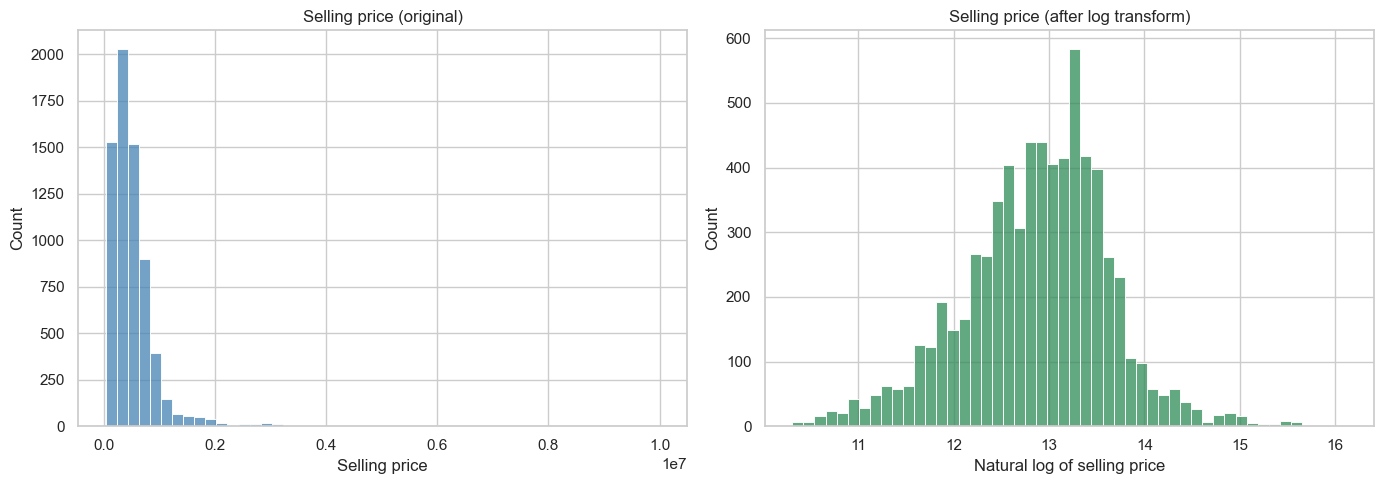

Skewness before log transform: 5.418
Skewness after  log transform: -0.186


In [24]:
# Part 1: The target variable
# Plotting the selling price before and after the log transform, side by side,
# so I can see exactly what the transform does to the shape of the data.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: the raw selling price
sns.histplot(df['selling_price'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Selling price (original)')
axes[0].set_xlabel('Selling price')

# Right plot: the same data after taking the natural logarithm
sns.histplot(np.log(df['selling_price']), bins=50, ax=axes[1], color='seagreen')
axes[1].set_title('Selling price (after log transform)')
axes[1].set_xlabel('Natural log of selling price')

plt.tight_layout()
plt.show()

# Skewness measures how lopsided a distribution is. A value of 0 means perfectly symmetric.
# Anything above about 1 is considered strongly skewed to the right.
print("Skewness before log transform:", round(df['selling_price'].skew(), 3))
print("Skewness after  log transform:", round(np.log(df['selling_price']).skew(), 3))

In [25]:
# Looking at the actual numbers behind that shape.
# I want to see how extreme the top end of the price range really is.

print("Price statistics:")
print(df['selling_price'].describe().round(0))

print("\nThe 5 most expensive cars in the dataset:")
print(df.nlargest(5, 'selling_price')[['brand', 'year', 'max_power', 'selling_price']])

# Working out what share of cars sit below a fairly ordinary price point
cheap_share = (df['selling_price'] < 1_000_000).mean() * 100
print(f"\nShare of cars priced under 1 million: {cheap_share:.1f} percent")

Price statistics:
count        6827.0
mean       517966.0
std        508165.0
min         29999.0
25%        250000.0
50%        409999.0
75%        640000.0
max      10000000.0
Name: selling_price, dtype: float64

The 5 most expensive cars in the dataset:
              brand  year  max_power  selling_price
167           Volvo  2017     400.00       10000000
2655            BMW  2020     265.00        7200000
133   Mercedes-Benz  2017     254.79        6000000
1010            BMW  2018     261.40        6000000
4088            BMW  2018     261.40        6000000

Share of cars priced under 1 million: 92.5 percent


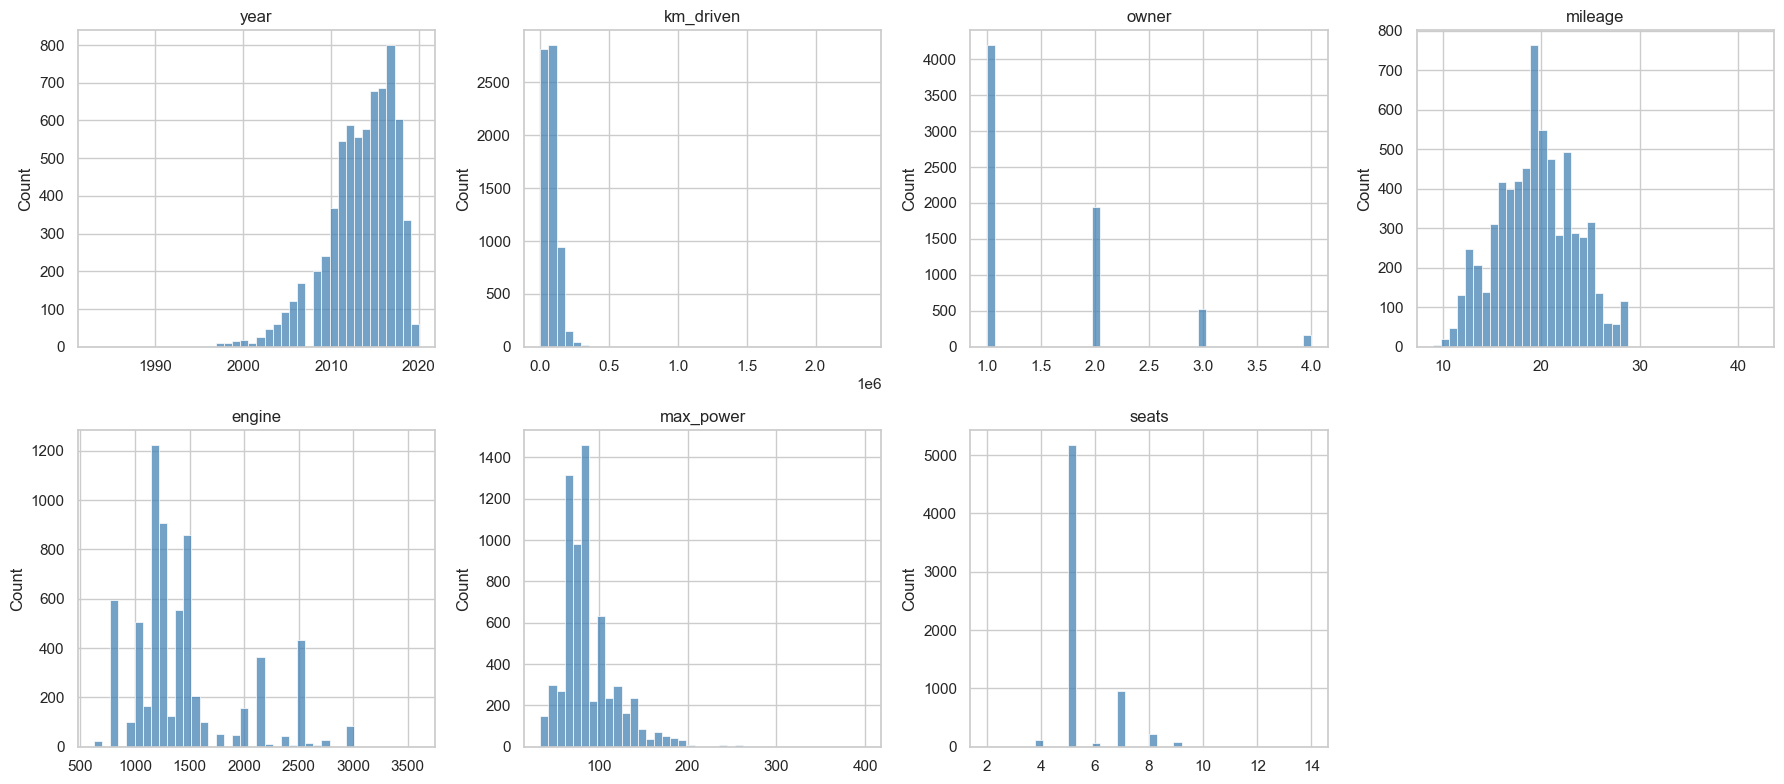

In [26]:
# Part 2: Distribution of each numeric feature
# Plotting a histogram for every numeric feature in one grid, rather than one plot per cell.
# Putting them together makes it much easier to compare their shapes at a glance.

features_to_plot = [c for c in numeric_cols if c != 'selling_price']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()   # turns the 2 by 4 grid into a simple list so I can loop over it

for i, col in enumerate(features_to_plot):
    sns.histplot(df[col].dropna(), bins=40, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Hiding any leftover empty boxes in the grid
for j in range(len(features_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [27]:
# Putting a number on the skewness of each feature instead of judging it by eye.
# This is what decides my mean versus median choice during imputation.

skew_table = pd.DataFrame({
    'skewness': df[features_to_plot].skew().round(2),
    'mean': df[features_to_plot].mean().round(2),
    'median': df[features_to_plot].median().round(2)
})

# A rule of thumb: below 0.5 is roughly symmetric, so the mean is safe.
# Above that the distribution is lopsided and the median is the safer choice.
skew_table['fill_with'] = np.where(skew_table['skewness'].abs() < 0.5, 'mean', 'median')
skew_table

,skewness,mean,median,fill_with
year,-1.00,2013.43,2014.00,median
km_driven,11.83,73992.95,70000.00,median
owner,1.42,1.51,1.00,median
mileage,0.03,19.48,19.40,mean
engine,1.20,1435.46,1248.00,median
max_power,1.71,88.06,81.86,median
seats,1.90,5.44,5.00,median


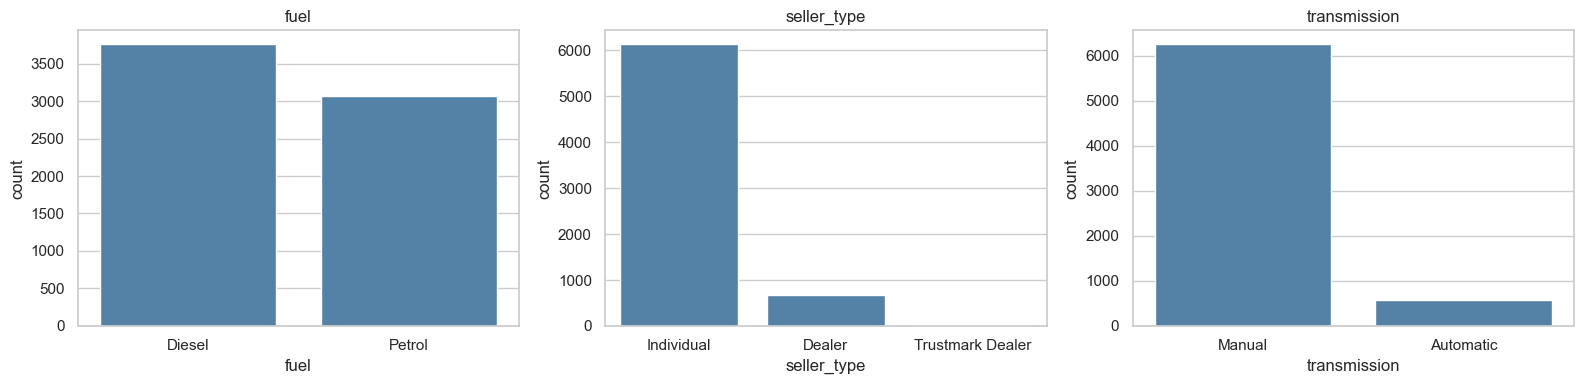

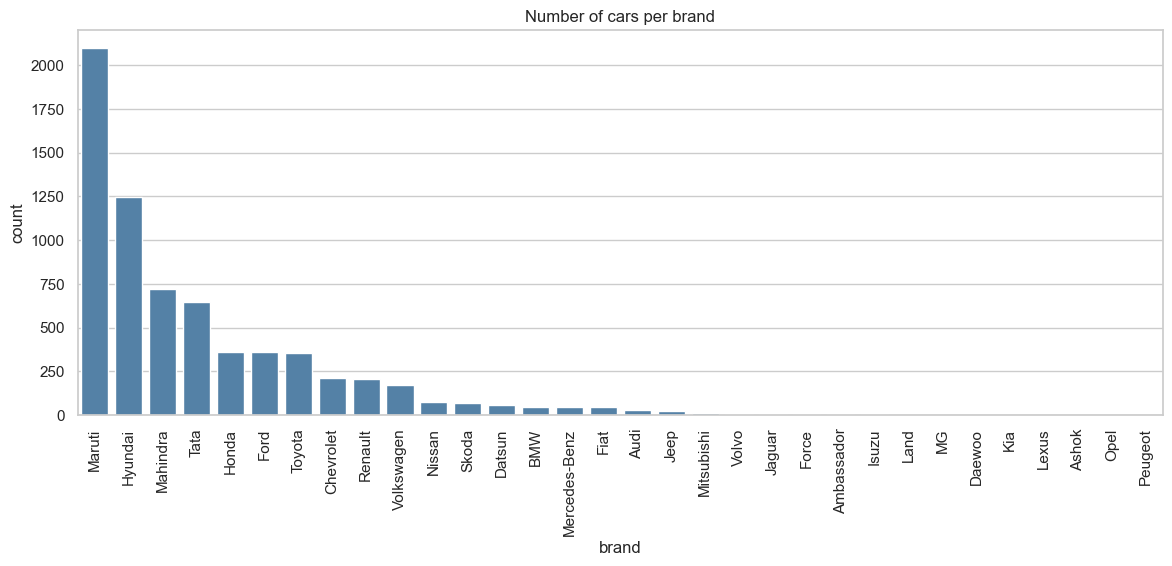

Cars per brand:
brand
Maruti           2096
Hyundai          1245
Mahindra          723
Tata              646
Honda             361
Ford              361
Toyota            357
Chevrolet         214
Renault           206
Volkswagen        173
Nissan             73
Skoda              70
Datsun             57
BMW                47
Mercedes-Benz      46
Fiat               44
Audi               30
Jeep               22
Mitsubishi         11
Volvo               9
Jaguar              8
Force               4
Ambassador          4
Isuzu               4
Land                3
MG                  3
Daewoo              3
Kia                 3
Lexus               1
Ashok               1
Opel                1
Peugeot             1
Name: count, dtype: int64


In [28]:
# Part 3: Distribution of the categorical features
# Counting how many cars fall into each category. I am checking for categories that are so
# rare that the model would have almost nothing to learn from them.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(['fuel', 'seller_type', 'transmission']):
    sns.countplot(data=df, x=col, ax=axes[i], color='steelblue')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# Brand has around 30 categories so it needs its own wider plot
plt.figure(figsize=(14, 5))
sns.countplot(data=df, x='brand', order=df['brand'].value_counts().index, color='steelblue')
plt.xticks(rotation=90)
plt.title('Number of cars per brand')
plt.show()

print("Cars per brand:")
print(df['brand'].value_counts())

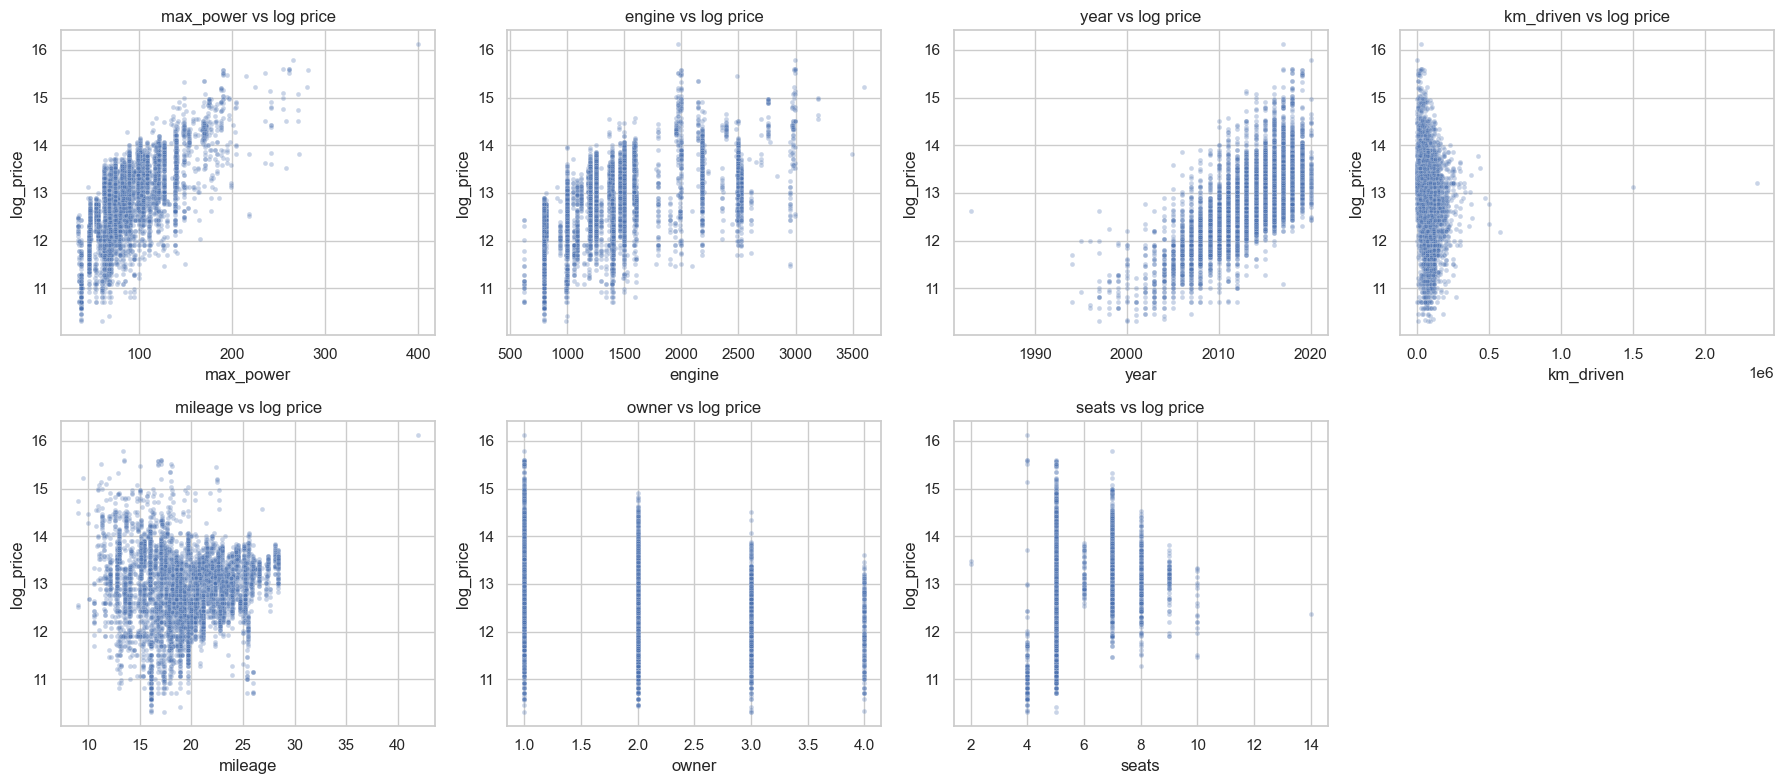

In [29]:
# Part 4: How each feature relates to the selling price
# Scatter plots of each numeric feature against the log of the selling price.
# I am looking for a visible upward or downward trend. A shapeless cloud means the feature
# on its own carries little information about price.

df['log_price'] = np.log(df['selling_price'])   # temporary helper column, just for plotting

scatter_features = ['max_power', 'engine', 'year', 'km_driven', 'mileage', 'owner', 'seats']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(scatter_features):
    sns.scatterplot(data=df, x=col, y='log_price', ax=axes[i], alpha=0.3, s=12)
    axes[i].set_title(f'{col} vs log price')

for j in range(len(scatter_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

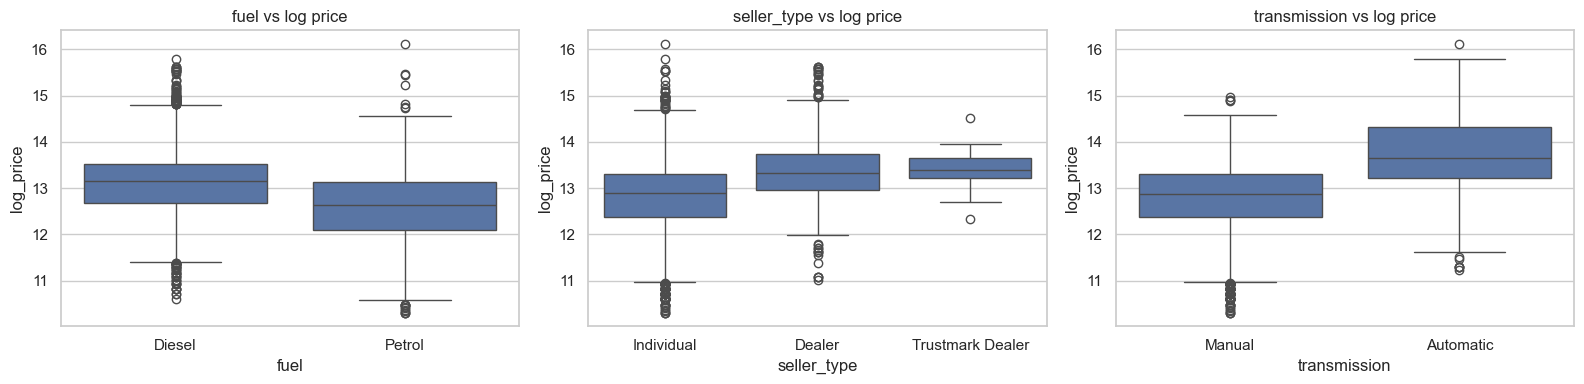

In [30]:
# For the categorical features a scatter plot makes no sense, so I use box plots instead.
# A box plot shows me the median and the spread of price inside each category, which tells
# me whether that category actually separates cheap cars from expensive ones.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(['fuel', 'seller_type', 'transmission']):
    sns.boxplot(data=df, x=col, y='log_price', ax=axes[i])
    axes[i].set_title(f'{col} vs log price')

plt.tight_layout()
plt.show()

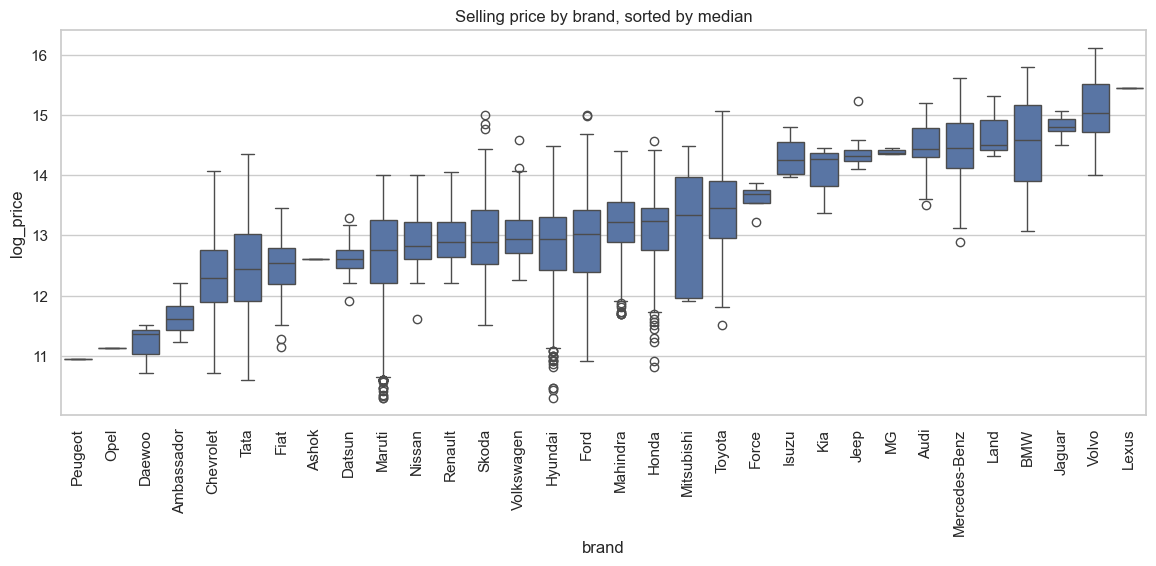

Average selling price by brand:
               count       mean
brand                          
Lexus              1  5150000.0
Volvo              9  4036111.0
BMW               47  2770638.0
Jaguar             8  2748250.0
Land               3  2716667.0
Mercedes-Benz     46  2253348.0
Audi              30  2042300.0
Jeep              22  1789227.0
MG                 3  1783333.0
Isuzu              4  1752500.0


In [31]:
# Brand deserves its own chart. I sort the brands by their median price so that the pattern
# is easy to read, instead of the brands appearing in a random order.

brand_order = df.groupby('brand')['log_price'].median().sort_values().index

plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x='brand', y='log_price', order=brand_order)
plt.xticks(rotation=90)
plt.title('Selling price by brand, sorted by median')
plt.show()

# The same information as a table, showing the average price per brand
print("Average selling price by brand:")
print(df.groupby('brand')['selling_price'].agg(['count', 'mean']).sort_values('mean', ascending=False).round(0).head(10))

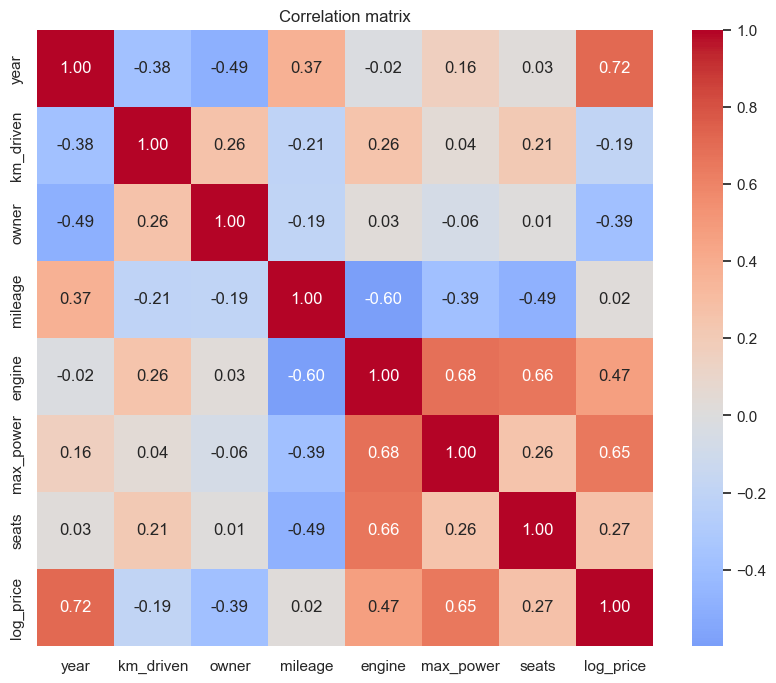

In [32]:
# Part 5: Correlation between features
# Building the correlation matrix on the numeric columns only, using the log price
# since that is what the model will actually be predicting.

corr_data = df[numeric_cols + ['log_price']].drop(columns=['selling_price'])
corr = corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlation matrix')
plt.show()

In [33]:
# Pulling out just the column I care about most, which is how each feature correlates
# with the price, sorted by strength so the ranking is obvious.

price_corr = corr['log_price'].drop('log_price').sort_values(key=abs, ascending=False)

print("Correlation with log price, strongest first:")
print(price_corr.round(3))

Correlation with log price, strongest first:
year         0.719
max_power    0.652
engine       0.472
owner       -0.389
seats        0.268
km_driven   -0.185
mileage      0.018
Name: log_price, dtype: float64


In [34]:
# Checking for pairs of features that are strongly correlated with each other.
# If two features carry almost the same information, keeping both adds complexity
# without adding much accuracy, and it makes the model harder to explain.

feature_corr = corr.drop(columns=['log_price']).drop(index=['log_price'])

print("Feature pairs correlated above 0.5 with each other:")
for i in range(len(feature_corr.columns)):
    for j in range(i + 1, len(feature_corr.columns)):
        value = feature_corr.iloc[i, j]
        if abs(value) > 0.5:
            print(f"  {feature_corr.columns[i]} and {feature_corr.columns[j]}: {value:.2f}")

Feature pairs correlated above 0.5 with each other:
  mileage and engine: -0.60
  engine and max_power: 0.68
  engine and seats: 0.66


In [35]:
# Removing the temporary helper column now that the plotting is finished.
# I do not want it sitting in my table by accident, because log_price is just another
# version of the target and including it as a feature would leak the answer to the model.

df = df.drop(columns=['log_price'])
print("Columns:", list(df.columns))

Columns: ['brand', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']


## Feature selection and the train test split

In [36]:

numeric_features = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'owner']

categorical_features = ['brand', 'fuel', 'seller_type', 'transmission']

target = 'selling_price'

print("Numeric features    :", len(numeric_features), numeric_features)
print("Categorical features:", len(categorical_features), categorical_features)
print("Target              :", target)

# A safety check that I have accounted for every single column and not silently forgotten one
all_accounted = set(numeric_features + categorical_features + [target])
assert all_accounted == set(df.columns), f"Column mismatch: {set(df.columns) - all_accounted}"
print("\nCheck passed: every column in the dataset is accounted for")

Numeric features    : 7 ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'owner']
Categorical features: 4 ['brand', 'fuel', 'seller_type', 'transmission']
Target              : selling_price

Check passed: every column in the dataset is accounted for


In [37]:
# Building X and y.
# X holds the inputs, which is every column except the price. Capital X is the usual
# convention because it is a table with many columns.
# y holds the answer, which is the price. Lowercase y because it is a single column.

X = df[numeric_features + categorical_features].copy()

# Applying the log transform.
# From now on every score I report is measured in log units, and at prediction time

y = np.log(df[target])

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("y before the log transform ranged from", df[target].min(), "to", df[target].max())
print("y after  the log transform ranges from", round(y.min(), 2), "to", round(y.max(), 2))

X.head()

X shape: (6827, 11)
y shape: (6827,)

y before the log transform ranged from 29999 to 10000000
y after  the log transform ranges from 10.31 to 16.12


,year,km_driven,mileage,engine,max_power,seats,owner,brand,fuel,seller_type,transmission
0,2014,145500,23.40,1248.0,74.00,5.0,1,Maruti,Diesel,Individual,Manual
1,2014,120000,21.14,1498.0,103.52,5.0,2,Skoda,Diesel,Individual,Manual
2,2006,140000,17.70,1497.0,78.00,5.0,3,Honda,Petrol,Individual,Manual
3,2010,127000,23.00,1396.0,90.00,5.0,1,Hyundai,Diesel,Individual,Manual
4,2007,120000,16.10,1298.0,88.20,5.0,1,Maruti,Petrol,Individual,Manual


# Data Splitting
## Choosing the split size

I use 20 percent for testing. With 6827 rows,
20 percent still leaves around 1366 cars in the test set, which is more than enough for a
stable estimate of performance, while giving the model an extra 680 cars to learn from.

There is no stratify option for regression the way there is for classification, so after
splitting I check that the price distribution came out similar in both halves.

In [38]:
from sklearn.model_selection import train_test_split

# Splitting the data. The function returns four things in this exact order:
# training inputs, testing inputs, training answers, testing answers.


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE   # the seed I fixed at the top of the notebook
)

print("X_train:", X_train.shape, "  y_train:", y_train.shape)
print("X_test :", X_test.shape, "  y_test :", y_test.shape)
print()
print(f"Training set: {len(X_train)} cars ({len(X_train)/len(X)*100:.1f} percent)")
print(f"Test set    : {len(X_test)} cars ({len(X_test)/len(X)*100:.1f} percent)")

X_train: (5461, 11)   y_train: (5461,)
X_test : (1366, 11)   y_test : (1366,)

Training set: 5461 cars (80.0 percent)
Test set    : 1366 cars (20.0 percent)


Log price distribution in each set:
          train      test
count  5461.000  1366.000
mean     12.875    12.846
std       0.765     0.746
min      10.309    10.358
25%      12.429    12.429
50%      12.936    12.899
75%      13.385    13.322
max      15.790    16.118


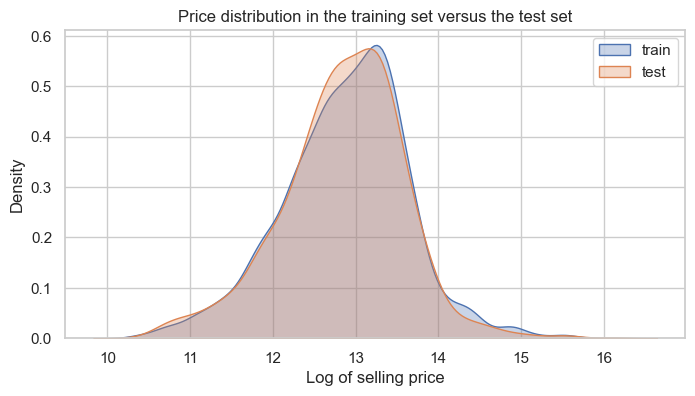

In [39]:
# Checking that the split is fair. Since the split is random there is a small chance it
# accidentally put most of the expensive cars on one side, which would make my test score
# misleading. Comparing the two distributions confirms that did not happen.

comparison = pd.DataFrame({
    'train': y_train.describe(),
    'test': y_test.describe()
}).round(3)

print("Log price distribution in each set:")
print(comparison)

# Plotting the two distributions on top of each other. If the split is fair,
# the two curves should sit almost exactly on top of one another.
plt.figure(figsize=(8, 4))
sns.kdeplot(y_train, label='train', fill=True, alpha=0.3)
sns.kdeplot(y_test, label='test', fill=True, alpha=0.3)
plt.xlabel('Log of selling price')
plt.title('Price distribution in the training set versus the test set')
plt.legend()
plt.show()

In [40]:
# A check that matters specifically because I have a categorical feature with around
# 30 categories. If a rare brand happens to land only in the test set, then my encoder
# will never have seen it during training and the model will not know what to do with it.
# I want to find that out now rather than getting a crash later.

for col in categorical_features:
    train_categories = set(X_train[col].unique())
    test_categories = set(X_test[col].unique())
    unseen = test_categories - train_categories

    print(f"{col}: {len(train_categories)} categories in train, {len(test_categories)} in test")
    if unseen:
        print(f"   Categories that appear only in the test set: {unseen}")
    else:
        print("   Every test category also appears in the training set")

brand: 31 categories in train, 23 in test
   Categories that appear only in the test set: {'Ashok'}
fuel: 2 categories in train, 2 in test
   Every test category also appears in the training set
seller_type: 3 categories in train, 3 in test
   Every test category also appears in the training set
transmission: 2 categories in train, 2 in test
   Every test category also appears in the training set


In [41]:
# Checking the missing values in each set. 

missing_check = pd.DataFrame({
    'train_missing': X_train.isnull().sum(),
    'train_percent': (X_train.isnull().sum() / len(X_train) * 100).round(2),
    'test_missing': X_test.isnull().sum(),
    'test_percent': (X_test.isnull().sum() / len(X_test) * 100).round(2)
})

print("Missing values on each side of the split:")
print(missing_check[missing_check['train_missing'] > 0])

Missing values on each side of the split:
           train_missing  train_percent  test_missing  test_percent
mileage              176           3.22            40          2.93
engine               161           2.95            40          2.93
max_power            161           2.95            40          2.93
seats                161           2.95            40          2.93


## Preprocessing

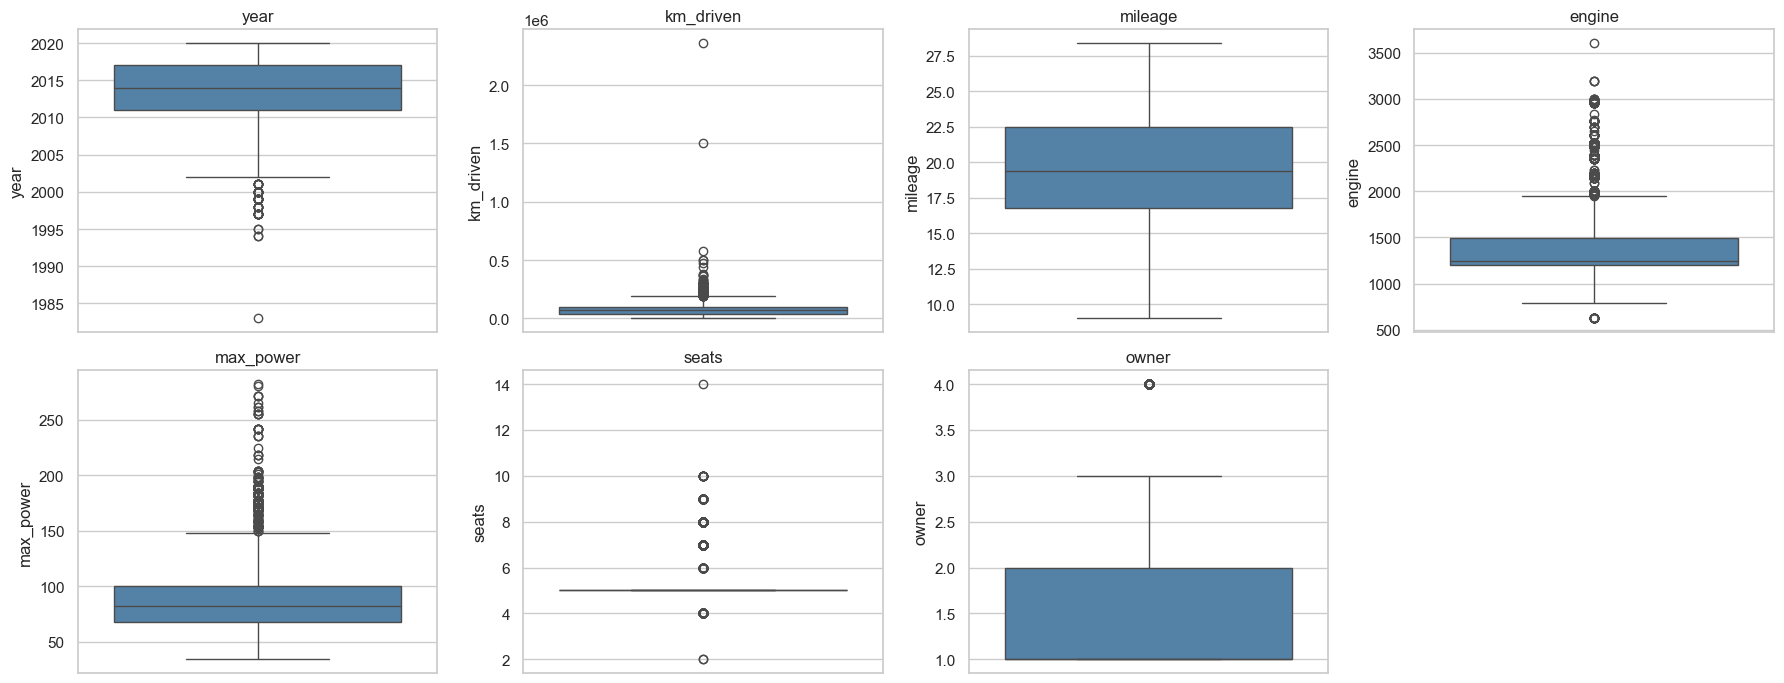

In [42]:
# Looking at the spread of each numeric feature with a box plot.
# The box covers the middle half of the data, the line inside it is the median, and the
# dots outside the whiskers are the points that sit far away from everything else.

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(y=X_train[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)

for j in range(len(numeric_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [43]:
# Counting the outliers properly instead of judging them by eye.
# I use the interquartile range rule, which is the standard method. It takes the middle
# fifty percent of the data as the normal range, then treats anything more than one and a
# half box widths outside that range as an outlier.

def count_outliers(data, column):
    """Counts how many values in a column fall outside the usual IQR boundaries."""
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    percent = len(outliers) / len(data) * 100

    return len(outliers), round(percent, 2), round(lower_bound, 2), round(upper_bound, 2)


outlier_summary = []
for col in numeric_features:
    count, percent, low, high = count_outliers(X_train, col)
    outlier_summary.append({
        'feature': col,
        'outliers': count,
        'percent': percent,
        'normal_range_low': low,
        'normal_range_high': high,
        'actual_max': round(X_train[col].max(), 2)
    })

pd.DataFrame(outlier_summary)

,feature,outliers,percent,normal_range_low,normal_range_high,actual_max
0,year,61,1.12,2002.00,2026.00,2020.0
1,km_driven,138,2.53,-50000.00,190000.00,2360457.0
2,mileage,0,0.00,8.25,31.05,28.4
3,engine,978,17.91,745.50,1949.50,3604.0
4,max_power,252,4.61,20.00,148.00,282.0
5,seats,1154,21.13,5.00,5.00,14.0
6,owner,135,2.47,-0.50,3.50,4.0


### My decision on outliers

I keep the outliers rather than removing them, for three reasons.

**They are mostly real cars, not errors.** A car with 400 bhp is genuinely a car with
400 bhp. Removing every powerful car would teach my model that expensive cars do not
exist, and then the app would badly underprice the exact cars where getting the price
right matters most to Chaky's company.

**My chosen model handles them well.** I plan to compare tree based models, which work by
splitting a feature at a threshold rather than fitting a line through it. One car sitting
far out on the right does not pull a tree the way it would pull a straight line.

**Removing them would shrink my data.** max_power alone flags several hundred rows, and
throwing away that much real data to make a chart look tidier is a poor trade.

The one value I am suspicious of is the maximum km_driven, which is over two million
kilometres. That is roughly fifty times around the world and is almost certainly a typing
error. However it is a single row out of 5461, so it cannot move the model much, and I
have no way of knowing what the true value should have been. I leave it in and note it here.

Because I am keeping the outliers, I use StandardScaler rather than MinMaxScaler.
MinMaxScaler squeezes everything into the range zero to one using the smallest and largest
values, so one extreme value at two million would push every ordinary car down into a tiny
band near zero. StandardScaler centres the data on its mean and divides by its spread,
which does not depend on the single most extreme value in the same way.

In [44]:
# In the EDA I decided that symmetric features should be filled with their mean and skewed
# features with their median, because the mean gets dragged around by extreme values while
# the median does not.
#
# I now recalculate the skewness on the TRAINING SET only. Earlier I measured it on the
# full dataset, which was fine for exploring, but this measurement feeds directly into how
# I fill the data, so it has to come from the training set alone.

train_skew = X_train[numeric_features].skew()

# Splitting the numeric features into two groups based on how lopsided they are
symmetric_features = train_skew[train_skew.abs() < 0.5].index.tolist()
skewed_features = train_skew[train_skew.abs() >= 0.5].index.tolist()

print("Skewness measured on the training set:")
print(train_skew.round(2))
print()
print("Roughly symmetric, will be filled with the mean  :", symmetric_features)
print("Skewed, will be filled with the median           :", skewed_features)

Skewness measured on the training set:
year         -1.01
km_driven    12.91
mileage       0.00
engine        1.19
max_power     1.60
seats         1.93
owner         1.44
dtype: float64

Roughly symmetric, will be filled with the mean  : ['mileage']
Skewed, will be filled with the median           : ['year', 'km_driven', 'engine', 'max_power', 'seats', 'owner']


## Building a preprocessing pipeline

I could apply imputation, scaling and encoding one line at a time, the way a beginner
tutorial would. Instead I bundle them into a single object called a Pipeline.

A pipeline is a set of steps wired together in a fixed order. When I call fit on it, every
step learns its numbers from the training data in sequence. When I later call transform or
predict, the exact same steps run in the exact same order with those same learned numbers.

I choose this for four practical reasons.

**It makes leakage almost impossible.** The pipeline only ever learns during fit. When it
sees the test set it can only transform, using what it already learned. I cannot
accidentally compute a test set median because there is no place in the code to do it.

**Cross validation becomes correct.** In the next step I compare five algorithms using
cross validation, which trains on four fifths of the training data and scores on the
remaining fifth, five times over. If I had scaled the data beforehand, every one of those
folds would have been scaled using information from the fold it is about to be scored on.
With a pipeline, the preprocessing is refitted inside each fold automatically.

**It makes the web application simple.** Task 3 requires a form where a user types in car
details and gets a price back. Without a pipeline I would have to remember the exact order
of every transformation and recreate it by hand in the app, and any small difference would
produce wrong prices with no error message. With a pipeline I save one file, load it in
the app, and call predict on the raw values the user typed.

**It solves the missing field requirement directly.** Task 3 says users must be allowed to
skip fields they do not know. Because the imputer lives inside the pipeline, a blank field
arriving from the web form is filled with the training median automatically, using exactly
the same number the model was trained with.

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Branch 1: numeric features that are roughly symmetric.
# Fill any gaps with the mean, then scale.
symmetric_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler())
])

# Branch 2: numeric features that are skewed.
# Fill any gaps with the median instead, then scale.
skewed_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# Branch 3: the text categories.
# There are no missing values in these columns right now, but I still include an imputer.
# The reason is Task 3: the web form lets users leave a field blank, so a missing brand or
# fuel type can arrive at prediction time even though it never appeared during training.
# most_frequent fills it with the commonest category from the training data.
#
# handle_unknown='ignore' is what solves the Ashok problem I found earlier. If a category
# turns up that the encoder never saw during training, it produces a row of zeros instead
# of crashing. That is the honest answer, because the model genuinely knows nothing about
# that brand.
categorical_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# The ColumnTransformer routes each group of columns down the correct branch and then
# glues the results back together into one table.
preprocessor = ColumnTransformer(
    transformers=[
        ('symmetric', symmetric_pipe, symmetric_features),
        ('skewed', skewed_pipe, skewed_features),
        ('categorical', categorical_pipe, categorical_features)
    ],
    remainder='drop'   # anything not listed above gets dropped, so nothing sneaks through
)

print("Preprocessor built.")
print("  Mean fill and scale :", symmetric_features)
print("  Median fill and scale:", skewed_features)
print("  Fill and one hot     :", categorical_features)

Preprocessor built.
  Mean fill and scale : ['mileage']
  Median fill and scale: ['year', 'km_driven', 'engine', 'max_power', 'seats', 'owner']
  Fill and one hot     : ['brand', 'fuel', 'seller_type', 'transmission']


In [46]:
from sklearn.base import clone

# clone makes an unfitted copy, so that fitting this one has no effect on the original
inspect_preprocessor = clone(preprocessor)

# fit_transform on the training set: learn the numbers, then apply them
X_train_prepared = inspect_preprocessor.fit_transform(X_train)

# transform only on the test set: apply the numbers already learned, learn nothing new.
# This one line is the whole leakage prevention rule in practice.
X_test_prepared = inspect_preprocessor.transform(X_test)

print("Before preprocessing:")
print("  X_train:", X_train.shape)
print("  X_test :", X_test.shape)
print()
print("After preprocessing:")
print("  X_train:", X_train_prepared.shape)
print("  X_test :", X_test_prepared.shape)
print()
print("The column count grew because one hot encoding turns each category into its own column.")

Before preprocessing:
  X_train: (5461, 11)
  X_test : (1366, 11)

After preprocessing:
  X_train: (5461, 45)
  X_test : (1366, 45)

The column count grew because one hot encoding turns each category into its own column.


In [47]:
# Getting the names of the columns that came out, so the result is readable
# rather than being an anonymous block of numbers.

feature_names = inspect_preprocessor.get_feature_names_out()

print("Total columns after preprocessing:", len(feature_names))
print()
print("First 15 column names:")
for name in feature_names[:15]:
    print("  ", name)
print("   ...")

Total columns after preprocessing: 45

First 15 column names:
   symmetric__mileage
   skewed__year
   skewed__km_driven
   skewed__engine
   skewed__max_power
   skewed__seats
   skewed__owner
   categorical__brand_Ambassador
   categorical__brand_Audi
   categorical__brand_BMW
   categorical__brand_Chevrolet
   categorical__brand_Daewoo
   categorical__brand_Datsun
   categorical__brand_Fiat
   categorical__brand_Force
   ...


In [48]:
# Confirming that the three things I wanted actually happened.

prepared_df = pd.DataFrame(X_train_prepared, columns=feature_names)

# Check 1: no missing values are left anywhere
print("Missing values remaining in the training data:", np.isnan(X_train_prepared).sum())
print("Missing values remaining in the test data    :", np.isnan(X_test_prepared).sum())

# Check 2: the numeric columns are scaled, meaning centred near zero with a spread near one
numeric_output = [c for c in feature_names if c.startswith(('symmetric__', 'skewed__'))]
print("\nScaled numeric columns, mean and standard deviation:")
print(prepared_df[numeric_output].agg(['mean', 'std']).round(3).T)

Missing values remaining in the training data: 0
Missing values remaining in the test data    : 0

Scaled numeric columns, mean and standard deviation:
                    mean  std
symmetric__mileage  -0.0  1.0
skewed__year         0.0  1.0
skewed__km_driven    0.0  1.0
skewed__engine      -0.0  1.0
skewed__max_power    0.0  1.0
skewed__seats        0.0  1.0
skewed__owner       -0.0  1.0


In [49]:
# Check 3: confirming that the unknown brand Ashok is handled without crashing.
# Ashok appears only in the test set, so the encoder never learned it during training.
# I expect all of its brand columns to come out as zero rather than throwing an error.

ashok_rows = X_test['brand'] == 'Ashok'
print("Number of Ashok cars in the test set:", ashok_rows.sum())

if ashok_rows.sum() > 0:
    brand_columns = [i for i, name in enumerate(feature_names) if 'brand_' in name]
    ashok_encoded = X_test_prepared[ashok_rows.values][:, brand_columns]

    print("Sum of the brand columns for those rows:", ashok_encoded.sum())
    print("As expected this is zero, which means the encoder handled the unknown brand")
    print("safely instead of crashing. The model simply has no brand information for that car")
    print("and relies on the other ten features instead.")

Number of Ashok cars in the test set: 1
Sum of the brand columns for those rows: 0.0
As expected this is zero, which means the encoder handled the unknown brand
safely instead of crashing. The model simply has no brand information for that car
and relies on the other ten features instead.


# A2: Predicting Car Price

This notebook continues from A1. The data cleaning, exploratory analysis, train test
split and preprocessing pipeline are carried over unchanged. The modelling section is
rebuilt from scratch.

A1 used ready made scikit-learn models. A2 uses a hand written LinearRegression class
based on notebook 03. The class is extended with an r2 method, a choice between zeros
and Xavier weight initialisation, optional momentum, and a feature importance plot
built from the learned coefficients.

Every experiment is tracked with MLflow. The best configuration is evaluated on the
test set and then deployed as a second page on the existing website.

## Task 1. Implementation

In [50]:
# %pip install mlflow

In [51]:
import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.preprocessing import OneHotEncoder

mlflow.set_experiment(experiment_name="a2-car-price-from-scratch")
print("Tracking to:", mlflow.get_tracking_uri())

Tracking to: sqlite:///D:/AIT%20SEM%202/ML/ML_Assignment/A2/mlflow.db


## Encoding

In [52]:
categorical_pipe_linear = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first',
                             handle_unknown='infrequent_if_exist',
                             sparse_output=False))
])

preprocessor_linear = ColumnTransformer(
    transformers=[
        ('symmetric', symmetric_pipe, symmetric_features),
        ('skewed', skewed_pipe, skewed_features),
        ('categorical', categorical_pipe_linear, categorical_features)
    ],
    remainder='drop'
)

prep = clone(preprocessor_linear)
X_train_prep = prep.fit_transform(X_train)
X_test_prep  = prep.transform(X_test)
feature_names = list(prep.get_feature_names_out())

print("X_train_prep:", X_train_prep.shape)
print("X_test_prep :", X_test_prep.shape)

X_train_prep: (5461, 41)
X_test_prep : (1366, 41)


c:\Users\tisab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


## Centring the target

In [53]:
y_train_np = y_train.to_numpy()
y_test_np  = y_test.to_numpy()

y_mean = y_train_np.mean()
y_train_c = y_train_np - y_mean
y_test_c  = y_test_np - y_mean

print("Training mean:", round(y_mean, 4))
print("Centred mean :", round(y_train_c.mean(), 6))

Training mean: 12.8753
Centred mean : 0.0


## Penalties

Ridge squares the weights. Lasso takes the absolute value and can drive a weight to zero.
Elastic net mixes both. NoPenalty gives plain linear regression.

The bias at index 0 is excluded from every penalty, since shrinking it would pull
predictions towards zero for no reason.

In [54]:
class LassoPenalty:
    def __init__(self, l):
        self.l = l

    def __call__(self, theta):
        return self.l * np.sum(np.abs(theta[1:]))

    def derivation(self, theta):
        grad = self.l * np.sign(theta)
        grad[0] = 0
        return grad


class RidgePenalty:
    def __init__(self, l):
        self.l = l

    def __call__(self, theta):
        return self.l * np.sum(np.square(theta[1:]))

    def derivation(self, theta):
        grad = self.l * 2 * theta
        grad[0] = 0
        return grad


class ElasticPenalty:
    def __init__(self, l=0.1, l_ratio=0.5):
        self.l = l
        self.l_ratio = l_ratio

    def __call__(self, theta):
        l1 = self.l_ratio * self.l * np.sum(np.abs(theta[1:]))
        l2 = (1 - self.l_ratio) * self.l * 0.5 * np.sum(np.square(theta[1:]))
        return l1 + l2

    def derivation(self, theta):
        grad = self.l * self.l_ratio * np.sign(theta) + \
               self.l * (1 - self.l_ratio) * theta
        grad[0] = 0
        return grad


class NoPenalty:
    def __init__(self, l=0):
        self.l = l

    def __call__(self, theta):
        return 0

    def derivation(self, theta):
        return np.zeros_like(theta)


print("Penalties defined")

Penalties defined


## The model

In [61]:
class LinearRegression(object):

    kfold = KFold(n_splits=3)

    def __init__(self, regularization, lr=0.001, method='batch', num_epochs=500,
                 batch_size=50, cv=kfold, init='zeros', use_momentum=False,
                 momentum=0.9, polynomial=False, degree=2, n_numeric=None):

        self.lr           = lr
        self.num_epochs   = num_epochs
        self.batch_size   = batch_size
        self.method       = method
        self.cv           = cv
        self.regularization = regularization
        self.init         = init
        self.use_momentum = use_momentum
        self.momentum     = momentum
        self.polynomial   = polynomial
        self.degree       = degree
        self.n_numeric    = n_numeric
        self.feature_names = None
        self.poly_mean    = None
        self.poly_std     = None

        if method not in ('batch', 'mini', 'sto'):
            raise ValueError("method must be 'batch', 'mini' or 'sto'")
        if init not in ('zeros', 'xavier'):
            raise ValueError("init must be 'zeros' or 'xavier'")

    # scoring
    def mse(self, ytrue, ypred):
        return ((ypred - ytrue) ** 2).sum() / ytrue.shape[0]

    def r2(self, ytrue, ypred):
        ss_res = ((ytrue - ypred) ** 2).sum()
        ss_tot = ((ytrue - ytrue.mean()) ** 2).sum()
        return 1 - (ss_res / ss_tot)

    def avg_mse(self):
        return np.mean(self.kfold_mse)

    def avg_r2(self):
        return np.mean(self.kfold_r2)

    # feature handling
    def _expand(self, X, names=None):
        """Squares and pairwise products for the numeric columns only."""
        k = self.n_numeric
        num, cat = X[:, :k], X[:, k:]

        products = []
        out_names = list(names[:k]) if names else None

        for i in range(k):
            for j in range(i, k):
                products.append((num[:, i] * num[:, j]).reshape(-1, 1))
                if names:
                    out_names.append(f"{names[i]} x {names[j]}")

        products = np.hstack(products)

        # Squaring an outlier that already sits 30 standard deviations out produces
        # values hundreds of times larger than the original columns, which makes the
        # gradient explode. Rescaling the new terms puts them back on a comparable
        # footing. Statistics come from the training data and are reused at predict time.
        if self.poly_mean is None:
            self.poly_mean = products.mean(axis=0)
            self.poly_std  = products.std(axis=0)
            self.poly_std[self.poly_std == 0] = 1

        products = (products - self.poly_mean) / self.poly_std

        if names:
            out_names += list(names[k:])

        return np.hstack([num, products, cat]), out_names

    def _prepare(self, X, names=None):
        if self.polynomial:
            X, names = self._expand(X, names)
        bias = np.ones((X.shape[0], 1))
        return np.concatenate((bias, X), axis=1), names

    def _init_theta(self, n):
        if self.init == 'xavier':
            limit = 1.0 / np.sqrt(n)
            return np.random.uniform(-limit, limit, size=n)
        return np.zeros(n)

    # training
    def fit(self, X_train, y_train, feature_names=None):
        X_train, self.feature_names = self._prepare(X_train, feature_names)

        self.kfold_mse = []
        self.kfold_r2  = []

        for fold, (tr, va) in enumerate(self.cv.split(X_train)):
            Xtr, ytr = X_train[tr], y_train[tr]
            Xva, yva = X_train[va], y_train[va]

            # fresh weights and momentum per fold
            self.theta     = self._init_theta(Xtr.shape[1])
            self.prev_step = np.zeros(Xtr.shape[1])
            val_loss_old   = np.inf

            with mlflow.start_run(run_name=f"Fold-{fold}", nested=True):
                mlflow.log_params({
                    "method": self.method, "lr": self.lr,
                    "reg": type(self).__name__, "init": self.init,
                    "momentum": self.momentum if self.use_momentum else 0,
                    "polynomial": self.polynomial
                })

                for epoch in range(self.num_epochs):
                    perm = np.random.permutation(Xtr.shape[0])
                    Xtr, ytr = Xtr[perm], ytr[perm]

                    if self.method == 'sto':
                        for i in range(Xtr.shape[0]):
                            train_loss = self._train(Xtr[i].reshape(1, -1), ytr[i].reshape(1,))
                    elif self.method == 'mini':
                        for i in range(0, Xtr.shape[0], self.batch_size):
                            train_loss = self._train(Xtr[i:i + self.batch_size],
                                                     ytr[i:i + self.batch_size])
                    else:
                        train_loss = self._train(Xtr, ytr)

                    yhat = Xva @ self.theta
                    val_loss = self.mse(yva, yhat)

                    mlflow.log_metric("train_loss", train_loss, step=epoch)
                    mlflow.log_metric("val_loss", val_loss, step=epoch)

                    if np.allclose(val_loss, val_loss_old):
                        break
                    val_loss_old = val_loss

                val_r2 = self.r2(yva, yhat)
                mlflow.log_metric("fold_mse", val_loss)
                mlflow.log_metric("fold_r2", val_r2)

                self.kfold_mse.append(val_loss)
                self.kfold_r2.append(val_r2)
                print(f"  Fold {fold}: mse {val_loss:.4f}, r2 {val_r2:.4f}")

    def _train(self, X, y):
        yhat = X @ self.theta
        m    = X.shape[0]
        grad = (1 / m) * X.T @ (yhat - y) + self.regularization.derivation(self.theta)

        if self.use_momentum:
            step = self.lr * grad + self.momentum * self.prev_step
            self.theta = self.theta - step
            self.prev_step = step
        else:
            self.theta = self.theta - self.lr * grad

        return self.mse(y, yhat)

    # prediction and inspection
    def predict(self, X):
        X, _ = self._prepare(X, None)
        return X @ self.theta

    def _coef(self):
        return self.theta[1:]

    def _bias(self):
        return self.theta[0]

    def feature_importance(self, top_n=15, figsize=(9, 6)):
        coefs = self._coef()
        names = self.feature_names or [f"f{i}" for i in range(len(coefs))]

        df = pd.DataFrame({'feature': names, 'coefficient': coefs})
        df['mag'] = df['coefficient'].abs()
        df = df.sort_values('mag', ascending=False).head(top_n)

        colours = ['steelblue' if c >= 0 else 'indianred' for c in df['coefficient']]

        plt.figure(figsize=figsize)
        plt.barh(df['feature'], df['coefficient'], color=colours)
        plt.axvline(0, color='black', linewidth=0.8)
        plt.xlabel('Coefficient')
        plt.title(f'Feature importance, top {len(df)}')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

        return df[['feature', 'coefficient']].reset_index(drop=True)


print("LinearRegression defined")

LinearRegression defined


## Model types

Four types share the same interface, so the experiment loop can treat them identically.

In [62]:
class Normal(LinearRegression):
    def __init__(self, l=0, **kw):
        super().__init__(NoPenalty(), **kw)

class Lasso(LinearRegression):
    def __init__(self, l=0.1, **kw):
        super().__init__(LassoPenalty(l), **kw)

class Ridge(LinearRegression):
    def __init__(self, l=0.1, **kw):
        super().__init__(RidgePenalty(l), **kw)

class ElasticNet(LinearRegression):
    def __init__(self, l=0.1, l_ratio=0.5, **kw):
        super().__init__(ElasticPenalty(l, l_ratio), **kw)


print("Model types defined")

Model types defined


## Setup

n_numeric tells the class where the numeric columns end, so polynomial expansion skips the
dummies.

In [63]:
n_numeric = sum(1 for n in feature_names
                if n.startswith(('symmetric__', 'skewed__')))

kfold_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

print("numeric columns:", n_numeric)
print("total columns  :", len(feature_names))

numeric columns: 7
total columns  : 41


## Test run

One configuration before the full experiment, to confirm the class works on this data.

In [64]:
import time
start = time.time()

with mlflow.start_run(run_name="test-run"):
    m = Ridge(l=0.01, lr=0.01, method='batch', num_epochs=500, cv=kfold_cv,
              init='xavier', use_momentum=True, momentum=0.9,
              polynomial=False, n_numeric=n_numeric)
    m.fit(X_train_prep, y_train_c, feature_names=feature_names)

print(f"\n{time.time() - start:.1f}s")
print("avg mse:", round(m.avg_mse(), 4), " avg r2:", round(m.avg_r2(), 4))
print("bias    :", round(m._bias(), 4), "  (centred target, so near 0 is correct)")

  Fold 0: mse 0.0806, r2 0.8669
  Fold 1: mse 0.0705, r2 0.8751
  Fold 2: mse 0.0792, r2 0.8652

25.0s
avg mse: 0.0768  avg r2: 0.8691
bias    : 0.1717   (centred target, so near 0 is correct)


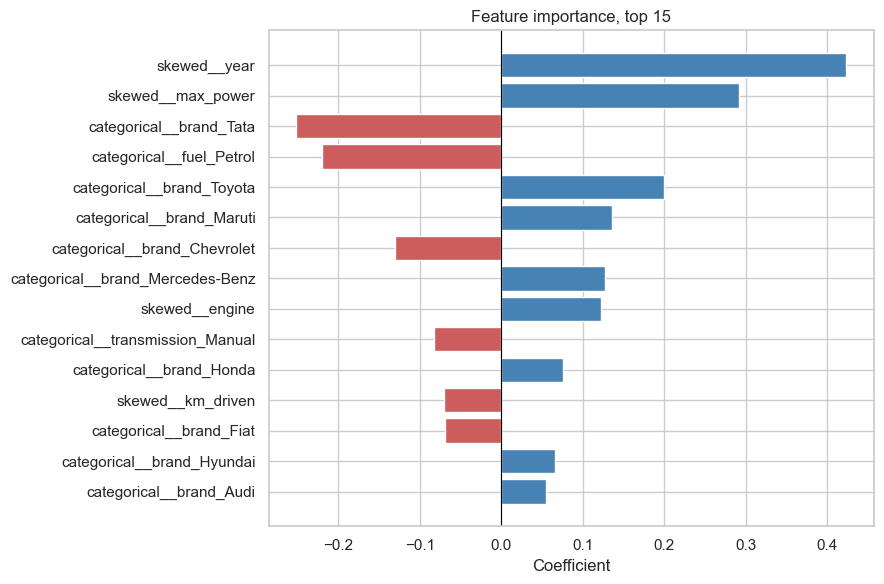

,feature,coefficient
0,skewed__year,0.423327
1,skewed__max_power,0.290970
2,categorical__brand_Tata,-0.251342
3,categorical__fuel_Petrol,-0.220310
4,categorical__brand_Toyota,0.199743
5,categorical__brand_Maruti,0.136288
6,categorical__brand_Chevrolet,-0.130872
7,categorical__brand_Mercedes-Benz,0.126858
8,skewed__engine,0.121799
9,categorical__transmission_Manual,-0.082870


In [65]:
m.feature_importance(top_n=15)

In [66]:
start = time.time()
with mlflow.start_run(run_name="test-poly"):
    mp = Normal(lr=0.01, method='batch', num_epochs=500, cv=kfold_cv,
                init='xavier', use_momentum=True, momentum=0.9,
                polynomial=True, n_numeric=n_numeric)
    mp.fit(X_train_prep, y_train_c, feature_names=feature_names)

print(f"\n{time.time() - start:.1f}s")
print("avg mse:", round(mp.avg_mse(), 4), " avg r2:", round(mp.avg_r2(), 4))
print("columns after expansion:", len(mp.feature_names))

  Fold 0: mse 0.0677, r2 0.8882
  Fold 1: mse 0.0629, r2 0.8885
  Fold 2: mse 0.0654, r2 0.8887

27.9s
avg mse: 0.0653  avg r2: 0.8885
columns after expansion: 69


## Task 2. Experiment

## Experiment grid

In [67]:
EPOCHS = {'batch': 500, 'mini': 50, 'sto': 5}

MODEL_TYPES = {
    'normal':     dict(cls=Normal,     poly=False),
    'lasso':      dict(cls=Lasso,      poly=False),
    'ridge':      dict(cls=Ridge,      poly=False),
    'polynomial': dict(cls=Normal,     poly=True),
}

grid = [
    (mt, mom, meth, ini, lr)
    for mt   in MODEL_TYPES
    for mom  in [True, False]
    for meth in ['batch', 'mini', 'sto']
    for ini  in ['zeros', 'xavier']
    for lr   in [0.01, 0.001, 0.0001]
]

print("configurations:", len(grid))

configurations: 144


In [68]:
results = []
start_all = time.time()

for i, (mt, mom, meth, ini, lr) in enumerate(grid, 1):

    spec = MODEL_TYPES[mt]
    name = f"{mt}-{meth}-lr{lr}-{ini}-mom{int(mom)}"
    print(f"[{i}/{len(grid)}] {name}")

    t0 = time.time()

    try:
        with mlflow.start_run(run_name=name):
            model = spec['cls'](
                lr=lr, method=meth, num_epochs=EPOCHS[meth], cv=kfold_cv,
                init=ini, use_momentum=mom, momentum=0.9,
                polynomial=spec['poly'], n_numeric=n_numeric
            )
            model.fit(X_train_prep, y_train_c, feature_names=feature_names)

            avg_mse = model.avg_mse()
            avg_r2  = model.avg_r2()

            # Diverged runs produce inf or nan, which MLflow rejects.
            if np.isfinite(avg_mse) and np.isfinite(avg_r2):
                mlflow.log_metric("avg_mse", avg_mse)
                mlflow.log_metric("avg_r2", avg_r2)

    except Exception as e:
        print("   failed:", e)
        avg_mse, avg_r2 = np.inf, -np.inf

    results.append({
        'model': mt, 'method': meth, 'lr': lr, 'init': ini, 'momentum': mom,
        'avg_mse': avg_mse, 'avg_r2': avg_r2, 'seconds': round(time.time() - t0, 1)
    })

results_df = pd.DataFrame(results)
results_df.to_csv('experiment_results.csv', index=False)

print(f"\nTotal: {(time.time() - start_all) / 60:.1f} minutes")
print("Diverged runs:", (~np.isfinite(results_df['avg_mse'])).sum())

[1/144] normal-batch-lr0.01-zeros-mom1
  Fold 0: mse 0.0798, r2 0.8682
  Fold 1: mse 0.0693, r2 0.8772
  Fold 2: mse 0.0769, r2 0.8692
[2/144] normal-batch-lr0.001-zeros-mom1
  Fold 0: mse 0.0902, r2 0.8510
  Fold 1: mse 0.0812, r2 0.8560
  Fold 2: mse 0.0918, r2 0.8438
[3/144] normal-batch-lr0.0001-zeros-mom1
  Fold 0: mse 0.2044, r2 0.6623
  Fold 1: mse 0.1891, r2 0.6648
  Fold 2: mse 0.2017, r2 0.6569
[4/144] normal-batch-lr0.01-xavier-mom1
  Fold 0: mse 0.0800, r2 0.8678
  Fold 1: mse 0.0698, r2 0.8764
  Fold 2: mse 0.0763, r2 0.8701
[5/144] normal-batch-lr0.001-xavier-mom1
  Fold 0: mse 0.0928, r2 0.8466
  Fold 1: mse 0.0917, r2 0.8375
  Fold 2: mse 0.1007, r2 0.8287
[6/144] normal-batch-lr0.0001-xavier-mom1
  Fold 0: mse 0.2428, r2 0.5987
  Fold 1: mse 0.2301, r2 0.5921
  Fold 2: mse 0.1867, r2 0.6823
[7/144] normal-mini-lr0.01-zeros-mom1
  Fold 0: mse 0.0779, r2 0.8712
  Fold 1: mse 0.0666, r2 0.8819
  Fold 2: mse 0.0766, r2 0.8698
[8/144] normal-mini-lr0.001-zeros-mom1
  Fold 0

C:\Users\tisab\AppData\Local\Temp\ipykernel_436\2790786352.py:32: RuntimeWarning: overflow encountered in square
  return ((ypred - ytrue) ** 2).sum() / ytrue.shape[0]
C:\Users\tisab\AppData\Local\Temp\ipykernel_436\2790786352.py:149: RuntimeWarning: overflow encountered in matmul
  grad = (1 / m) * X.T @ (yhat - y) + self.regularization.derivation(self.theta)
C:\Users\tisab\AppData\Local\Temp\ipykernel_436\2790786352.py:149: RuntimeWarning: invalid value encountered in matmul
  grad = (1 / m) * X.T @ (yhat - y) + self.regularization.derivation(self.theta)
C:\Users\tisab\AppData\Local\Temp\ipykernel_436\2790786352.py:152: RuntimeWarning: invalid value encountered in add
  step = self.lr * grad + self.momentum * self.prev_step
C:\Users\tisab\AppData\Local\Temp\ipykernel_436\2790786352.py:147: RuntimeWarning: invalid value encountered in matmul
  yhat = X @ self.theta


  Fold 0: mse nan, r2 nan
  Fold 1: mse nan, r2 nan
  Fold 2: mse nan, r2 nan
[122/144] polynomial-sto-lr0.001-zeros-mom1
  Fold 0: mse 17381849674785292.0000, r2 -28722484611917636.0000
  Fold 1: mse 26861834548018516328448.0000, r2 -47612471722764249595904.0000
  Fold 2: mse 0.1028, r2 0.8251
[123/144] polynomial-sto-lr0.0001-zeros-mom1
  Fold 0: mse 7.3598, r2 -11.1616
  Fold 1: mse 0.0816, r2 0.8554
  Fold 2: mse 0.0820, r2 0.8605
[124/144] polynomial-sto-lr0.01-xavier-mom1


C:\Users\tisab\AppData\Local\Temp\ipykernel_436\2790786352.py:35: RuntimeWarning: overflow encountered in square
  ss_res = ((ytrue - ypred) ** 2).sum()


  Fold 0: mse inf, r2 -inf
  Fold 1: mse nan, r2 nan
  Fold 2: mse nan, r2 nan
[125/144] polynomial-sto-lr0.001-xavier-mom1
  Fold 0: mse 9289624074677510144.0000, r2 -15350557594712387584.0000
  Fold 1: mse 201992286059942304.0000, r2 -358030349381142400.0000
  Fold 2: mse 30.5853, r2 -51.0364
[126/144] polynomial-sto-lr0.0001-xavier-mom1
  Fold 0: mse 26.8827, r2 -43.4221
  Fold 1: mse 133.3375, r2 -235.3400
  Fold 2: mse 0.0732, r2 0.8755
[127/144] polynomial-batch-lr0.01-zeros-mom0
  Fold 0: mse 0.0827, r2 0.8633
  Fold 1: mse 0.0748, r2 0.8674
  Fold 2: mse 0.0870, r2 0.8520
[128/144] polynomial-batch-lr0.001-zeros-mom0
  Fold 0: mse 0.1974, r2 0.6738
  Fold 1: mse 0.1800, r2 0.6810
  Fold 2: mse 0.1952, r2 0.6679
[129/144] polynomial-batch-lr0.0001-zeros-mom0
  Fold 0: mse 0.4874, r2 0.1946
  Fold 1: mse 0.4541, r2 0.1952
  Fold 2: mse 0.4737, r2 0.1941
[130/144] polynomial-batch-lr0.01-xavier-mom0
  Fold 0: mse 0.0869, r2 0.8564
  Fold 1: mse 0.0798, r2 0.8585
  Fold 2: mse 0.08

## Results

Runs with an mse above 1 have diverged, since predicting the training mean alone scores
about 0.6. They are kept in the table but excluded from the ranking.

In [69]:
res = pd.read_csv('experiment_results.csv')

res['diverged'] = ~np.isfinite(res['avg_mse']) | (res['avg_mse'] > 1)
ok = res[~res['diverged']].sort_values('avg_mse').reset_index(drop=True)

print("total:", len(res), " diverged:", res['diverged'].sum(), " usable:", len(ok))
print()
print(ok.head(10)[['model','method','lr','init','momentum','avg_mse','avg_r2']].round(4).to_string(index=False))

total: 144  diverged: 11  usable: 133

     model method    lr   init  momentum  avg_mse  avg_r2
polynomial  batch 0.010  zeros      True   0.0673  0.8851
polynomial   mini 0.010 xavier     False   0.0675  0.8848
polynomial   mini 0.010  zeros     False   0.0684  0.8832
polynomial   mini 0.001  zeros      True   0.0684  0.8832
polynomial  batch 0.010 xavier      True   0.0691  0.8820
    normal   mini 0.010  zeros      True   0.0737  0.8743
    normal  batch 0.010  zeros      True   0.0753  0.8715
    normal    sto 0.001  zeros      True   0.0753  0.8716
    normal  batch 0.010 xavier      True   0.0754  0.8714
    normal   mini 0.001  zeros      True   0.0758  0.8707


## Comparison by dimension

Median of the runs that converged, plus how many diverged in each group.

In [70]:
def summarise(col):
    g = res.groupby(col).agg(
        runs=('avg_mse', 'size'),
        diverged=('diverged', 'sum'),
        median_mse=('avg_mse', lambda s: s[np.isfinite(s) & (s < 1)].median()),
        best_mse=('avg_mse', lambda s: s[np.isfinite(s) & (s < 1)].min())
    ).round(4)
    print(f"\nBy {col}")
    print(g.to_string())

for c in ['model', 'method', 'lr', 'init', 'momentum']:
    summarise(c)


By model
            runs  diverged  median_mse  best_mse
model                                           
lasso         36         0      0.1310    0.1186
normal        36         0      0.0894    0.0737
polynomial    36        11      0.0925    0.0673
ridge         36         0      0.1012    0.0948

By method
        runs  diverged  median_mse  best_mse
method                                      
batch     48         0      0.1629    0.0673
mini      48         2      0.0974    0.0675
sto       48         9      0.1159    0.0753

By lr
        runs  diverged  median_mse  best_mse
lr                                          
0.0001    48         2      0.1949    0.0801
0.0010    48         3      0.1000    0.0684
0.0100    48         6      0.0969    0.0673

By init
        runs  diverged  median_mse  best_mse
init                                        
xavier    72         6      0.1189    0.0675
zeros     72         5      0.1186    0.0673

By momentum
          runs  diverged  

## Best configuration

Several configurations sit within a few thousandths of each other, which is inside the
variation between folds. The lowest is taken, and the close alternatives are noted in the
report.

In [71]:
best = ok.iloc[0]
print(best[['model','method','lr','init','momentum','avg_mse','avg_r2']].to_string())
print()
print("Within 0.005 of the best:")
print(ok[ok['avg_mse'] < best['avg_mse'] + 0.005]
      [['model','method','lr','init','momentum','avg_mse','avg_r2']].round(4).to_string(index=False))

model       polynomial
method           batch
lr                0.01
init             zeros
momentum          True
avg_mse       0.067284
avg_r2        0.885145

Within 0.005 of the best:
     model method    lr   init  momentum  avg_mse  avg_r2
polynomial  batch 0.010  zeros      True   0.0673  0.8851
polynomial   mini 0.010 xavier     False   0.0675  0.8848
polynomial   mini 0.010  zeros     False   0.0684  0.8832
polynomial   mini 0.001  zeros      True   0.0684  0.8832
polynomial  batch 0.010 xavier      True   0.0691  0.8820


## Final model

The top five configurations sit within 0.002 of each other, which is smaller than the
variation between folds, so they are tied. All five use polynomial features and four use a
learning rate of 0.01, so that combination is the real finding. The lowest scoring
configuration is taken as the final model.

The test set has not been touched until this point.

In [72]:
final = Normal(lr=0.01, method='batch', num_epochs=500, cv=kfold_cv,
               init='zeros', use_momentum=True, momentum=0.9,
               polynomial=True, n_numeric=n_numeric)

with mlflow.start_run(run_name="final-model"):
    final.fit(X_train_prep, y_train_c, feature_names=feature_names)

print("\ncv mse:", round(final.avg_mse(), 4), " cv r2:", round(final.avg_r2(), 4))

  Fold 0: mse 0.0666, r2 0.8900
  Fold 1: mse 0.0619, r2 0.8904
  Fold 2: mse 0.0734, r2 0.8751

cv mse: 0.0673  cv r2: 0.8851


## Test set results

Predictions are shifted back by the training mean, so scores are on the same log scale
used in A1.

In [73]:
y_pred_c = final.predict(X_test_prep)
y_pred   = y_pred_c + y_mean

test_mse = final.mse(y_test_np, y_pred)
test_r2  = final.r2(y_test_np, y_pred)

print("Test mse:", round(test_mse, 4))
print("Test r2 :", round(test_r2, 4))
print()
print("cv mse  :", round(final.avg_mse(), 4), " (close values mean the cv estimate was honest)")

with mlflow.start_run(run_name="final-test"):
    mlflow.log_metric("test_mse", test_mse)
    mlflow.log_metric("test_r2", test_r2)

Test mse: 0.0644
Test r2 : 0.8841

cv mse  : 0.0673  (close values mean the cv estimate was honest)


## Errors in baht

Log units are hard to read, so the errors are converted back to prices.

In [76]:
actual    = np.exp(y_test_np)
predicted = np.exp(y_pred)
pct_error = np.abs(actual - predicted) / actual * 100

print("Median absolute error :", f"{np.median(np.abs(actual - predicted)):,.0f} rupees")
print("Median percent error  :", f"{np.median(pct_error):.1f} percent")
print()
for t in [10, 20, 30]:
    print(f"Within {t} percent: {(pct_error <= t).mean() * 100:.1f} percent of cars")

Median absolute error : 54,712 rupees
Median percent error  : 14.5 percent

Within 10 percent: 35.1 percent of cars
Within 20 percent: 62.8 percent of cars
Within 30 percent: 81.3 percent of cars


## Feature importance

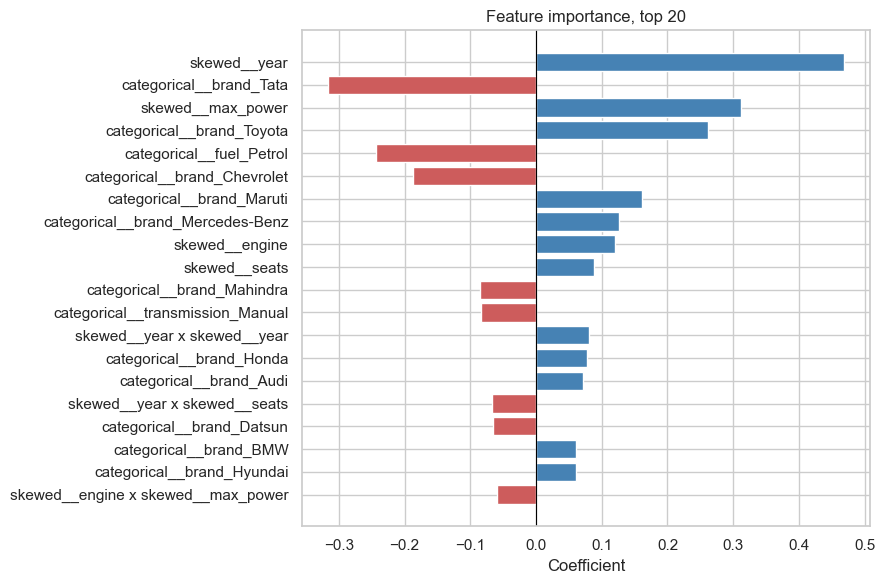

,feature,coefficient
0,skewed__year,0.468940
1,categorical__brand_Tata,-0.317030
2,skewed__max_power,0.312140
3,categorical__brand_Toyota,0.261532
4,categorical__fuel_Petrol,-0.243657
5,categorical__brand_Chevrolet,-0.187573
6,categorical__brand_Maruti,0.161736
7,categorical__brand_Mercedes-Benz,0.126241
8,skewed__engine,0.119470
9,skewed__seats,0.088786


In [77]:
importance = final.feature_importance(top_n=20)
importance

## Saving the model

In [78]:
import pickle, json, os

os.makedirs('model', exist_ok=True)

artefacts = {
    'theta':        final.theta,
    'preprocessor': prep,
    'y_mean':       y_mean,
    'poly_mean':    final.poly_mean,
    'poly_std':     final.poly_std,
    'n_numeric':    n_numeric,
    'polynomial':   final.polynomial,
    'feature_names': final.feature_names,
}

with open('model/a2_model.pkl', 'wb') as f:
    pickle.dump(artefacts, f)

size_kb = os.path.getsize('model/a2_model.pkl') / 1024
print(f"Saved model/a2_model.pkl  ({size_kb:.1f} KB)")

Saved model/a2_model.pkl  (6.9 KB)


## Prediction function

In [79]:
def predict_price(raw_df, art):
    """Predicts selling price in rupees from a dataframe of raw car details."""

    X = art['preprocessor'].transform(raw_df)

    if art['polynomial']:
        k = art['n_numeric']
        num, cat = X[:, :k], X[:, k:]

        products = np.hstack([(num[:, i] * num[:, j]).reshape(-1, 1)
                              for i in range(k) for j in range(i, k)])
        products = (products - art['poly_mean']) / art['poly_std']
        X = np.hstack([num, products, cat])

    X = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)

    log_price = X @ art['theta'] + art['y_mean']
    return np.exp(log_price)

## Verification

In [80]:
with open('model/a2_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

from_file     = predict_price(X_test, loaded)
from_notebook = np.exp(final.predict(X_test_prep) + y_mean)

match = np.allclose(from_file, from_notebook)
print("Predictions match:", match)
print("Largest difference:", f"{np.abs(from_file - from_notebook).max():.10f}")

assert match, "Saved model does not reproduce the notebook results"

Predictions match: True
Largest difference: 0.0000000000


c:\Users\tisab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)


## Metadata

Dropdown options and input ranges for the web form, plus the recorded scores.

In [81]:
metadata = {
    'model': 'Normal regression, polynomial degree 2, batch gradient descent',
    'params': {'lr': 0.01, 'init': 'zeros', 'momentum': 0.9, 'epochs': 500},
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'brands': sorted(X_train['brand'].unique().tolist()),
    'fuel_types': sorted(X_train['fuel'].unique().tolist()),
    'seller_types': sorted(X_train['seller_type'].unique().tolist()),
    'transmission_types': sorted(X_train['transmission'].unique().tolist()),
    'feature_ranges': {c: {'min': float(X_train[c].min()),
                           'max': float(X_train[c].max()),
                           'median': float(X_train[c].median())}
                       for c in numeric_features},
    'performance': {'cv_mse': round(float(final.avg_mse()), 4),
                    'test_mse': round(float(test_mse), 4),
                    'test_r2': round(float(test_r2), 4),
                    'median_percent_error': round(float(np.median(pct_error)), 1)},
}

with open('model/a2_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved model/a2_metadata.json")
print("File size of model:", f"{size_kb:.1f} KB")

Saved model/a2_metadata.json
File size of model: 6.9 KB


# Report

## What was built

A linear regression class trained by gradient descent, with options for weight
initialisation, momentum, polynomial features and three penalty types. The data cleaning,
feature selection and train test split were carried over from A1 unchanged.

## Experiment

144 configurations were compared: four model types, momentum on or off, three descent
methods, two initialisations and three learning rates. Each was cross validated over three
folds and logged to MLflow, giving 432 fold runs in total.

Epoch counts were scaled per method. One epoch is a single weight update for batch, 73 for
mini batch and 3640 for stochastic. Equal epochs would have meant stochastic doing thousands
of times more work than batch, so batch ran 500 epochs, mini batch 50 and stochastic 5,
which keeps total updates within a comparable range.

Runs scoring above an mse of 1 are treated as diverged, since predicting the training mean
alone scores about 0.6. Eleven of the 144 diverged and are excluded from the ranking.

## Results by dimension

| Dimension | Option | Median mse | Best mse | Diverged |
|---|---|---|---|---|
| Model | polynomial | 0.0925 | 0.0673 | 11 |
| | normal | 0.0894 | 0.0737 | 0 |
| | ridge | 0.1012 | 0.0948 | 0 |
| | lasso | 0.1310 | 0.1186 | 0 |
| Method | mini | 0.0974 | 0.0675 | 2 |
| | sto | 0.1159 | 0.0753 | 9 |
| | batch | 0.1629 | 0.0673 | 0 |
| Learning rate | 0.01 | 0.0969 | 0.0673 | 6 |
| | 0.001 | 0.1000 | 0.0684 | 3 |
| | 0.0001 | 0.1949 | 0.0801 | 2 |
| Initialisation | zeros | 0.1186 | 0.0673 | 5 |
| | xavier | 0.1189 | 0.0675 | 6 |
| Momentum | on | 0.1000 | 0.0673 | 8 |
| | off | 0.1287 | 0.0675 | 3 |

## Findings

**Polynomial features gave the best scores but were the only source of divergence.** All
eleven failed runs were polynomial. The expanded terms are products of values that are
already extreme, so the gradient is far more fragile. The gain was modest, from 0.0737 for
the plain model to 0.0673, and the interaction terms appear low in the importance chart at
coefficients of 0.08 and below. The relationship is mostly linear, with a small curved
component.

**Both penalties lost to no penalty at all.** Lasso scored 0.1186 and ridge 0.0948 against
0.0737 for the unpenalised model. Lambda was held at 0.1 for every penalised run and never
tuned, so at that strength the penalty shrinks useful coefficients rather than only noise.
The conclusion is about this lambda, not about regularisation in general. Lasso suffered
more than ridge, which fits their definitions, since the L1 penalty can drive a coefficient
to exactly zero while L2 only shrinks it.

**Initialisation made almost no difference.** Medians of 0.1186 and 0.1189, and best scores
0.0002 apart. Squared error with a linear model is convex, so there is a single minimum and
the starting point affects how fast it is reached rather than where it ends. With the
features already standardised, zeros is not a bad starting point, which is the situation
Xavier is designed to rescue.

**Momentum improved the median but caused more failures.** 0.1000 against 0.1287 on the
median, with eight divergences against three. It reaches the minimum faster and overshoots
more often. A clear demonstration of this appeared in the grid itself: momentum 0.9 at a
learning rate of 0.001 scored 0.0902, and no momentum at 0.01 scored 0.0901. Momentum 0.9
multiplies the effective step by 1 divided by 1 minus 0.9, which is ten, so a tenth of the
learning rate with momentum matches the full rate without it.

**Batch had the worst median but tied for the best single run.** Its median is dragged down
by the low learning rates, where one update per epoch is not enough progress in 500 epochs.
Given a large enough learning rate it is the most stable method, with no divergences at all.

## Two corrections to the provided code

**Momentum.** The pseudocode in the brief writes the update as theta minus step plus
momentum times the previous step. When the gradient points the same way for several epochs,
step and previous step are nearly equal, so subtracting one and adding 0.9 of the other
leaves a net movement of only a tenth of a step. At momentum 0.9 that slows training
tenfold rather than speeding it up. A first test run using that form scored an mse of 8.60
and an r2 of -13.7. Rewriting it as step equals learning rate times gradient plus momentum
times previous step, then subtracting, dropped the same configuration to 0.0987. The brief's
own description of momentum, that it increases updates for dimensions whose gradients point
in the same direction, matches the second form.

**Encoding.** A1 encoded every category as its own column. A full set of dummies sums to 1
on every row, which is identical to the bias column, so the model held several duplicate
copies of the intercept. A check found only 7.50 of an intercept of 12.88 sitting in
theta[0], with the remaining 5.33 spread across the categorical columns. Prediction was
unaffected, since the pieces add back up, but the coefficients could not be read as feature
effects. Dropping one category per group fixed it. Tree models are unaffected by this,
which is why it did not arise in A1.

## Two decisions worth recording

**Polynomial expansion was applied to the numeric columns only.** Of the 41 columns, 34 are
one hot flags holding 0 or 1. Squaring such a column returns the same column, and
multiplying two brand flags gives a column of zeros, since a car has exactly one brand.
Expanding all 41 would produce around 900 columns of which most carry no information.
Expanding the seven numeric columns alone gives 69 columns in total. The new terms are also
rescaled after expansion, because km_driven contains a value of 2.36 million that sits about
30 standard deviations out, and squaring it produced values large enough to overflow the
gradient.

**The target was centred before training.** Log price averages 12.88, so the intercept has
to climb that far before the model predicts anything sensible. At a learning rate of 0.0001
almost the entire training budget went into that climb rather than into the feature weights.
Subtracting the training mean starts the intercept at its correct value of zero. The mean is
added back before scoring, so every number reported here is on the original log scale and
stays comparable with A1.

## Final model

Normal regression on polynomial features, batch gradient descent, learning rate 0.01, zeros
initialisation, momentum 0.9, 500 epochs.

| Metric | Cross validation | Test set |
|---|---|---|
| mse | 0.0673 | 0.0644 |
| r2 | 0.8851 | 0.8841 |

The two are close, so the cross validation estimate was honest and no information leaked
from the test set.

The top five configurations sat between 0.0673 and 0.0691, a spread smaller than the
variation between folds, so they are tied. All five used polynomial features and four used a
learning rate of 0.01. That combination is the real finding rather than the exact winner.

In rupees, the median error is 54,712, which is 14.5 percent of the true price. 62.8 percent
of cars are priced within 20 percent and 81.3 percent within 30 percent.

## Comparison with A1

| | A1 | A2 |
|---|---|---|
| Model | Random Forest, tuned | Linear regression from scratch |
| Test mse | 0.0519 | 0.0644 |
| Test r2 | 0.8955 | 0.8841 |
| File size | 9.5 MB | 6.9 KB |

The forest is more accurate, by about 24 percent on mse. The scratch model is roughly 1,400
times smaller, predicts with a single matrix multiplication, and exposes a coefficient per
feature that can be read directly. For a web application serving one car at a time, the
accuracy difference is around 2 percentage points of median error while the size difference
is three orders of magnitude.

## Feature importance

Year has the largest coefficient at 0.469, followed by max_power at 0.312. Both positive,
matching the correlation analysis in A1. Manual transmission is negative, so automatics sell
higher. Petrol is negative relative to diesel. Tata and Chevrolet sit well below the
reference brand while Toyota, Mercedes and BMW sit above.

Two scales are mixed in this chart. The numeric coefficients are per standard deviation,
since those columns were standardised. The brand coefficients are differences from the
dropped reference category. Comparing a numeric bar directly against a brand bar therefore
overstates the numeric one.

## MLflow

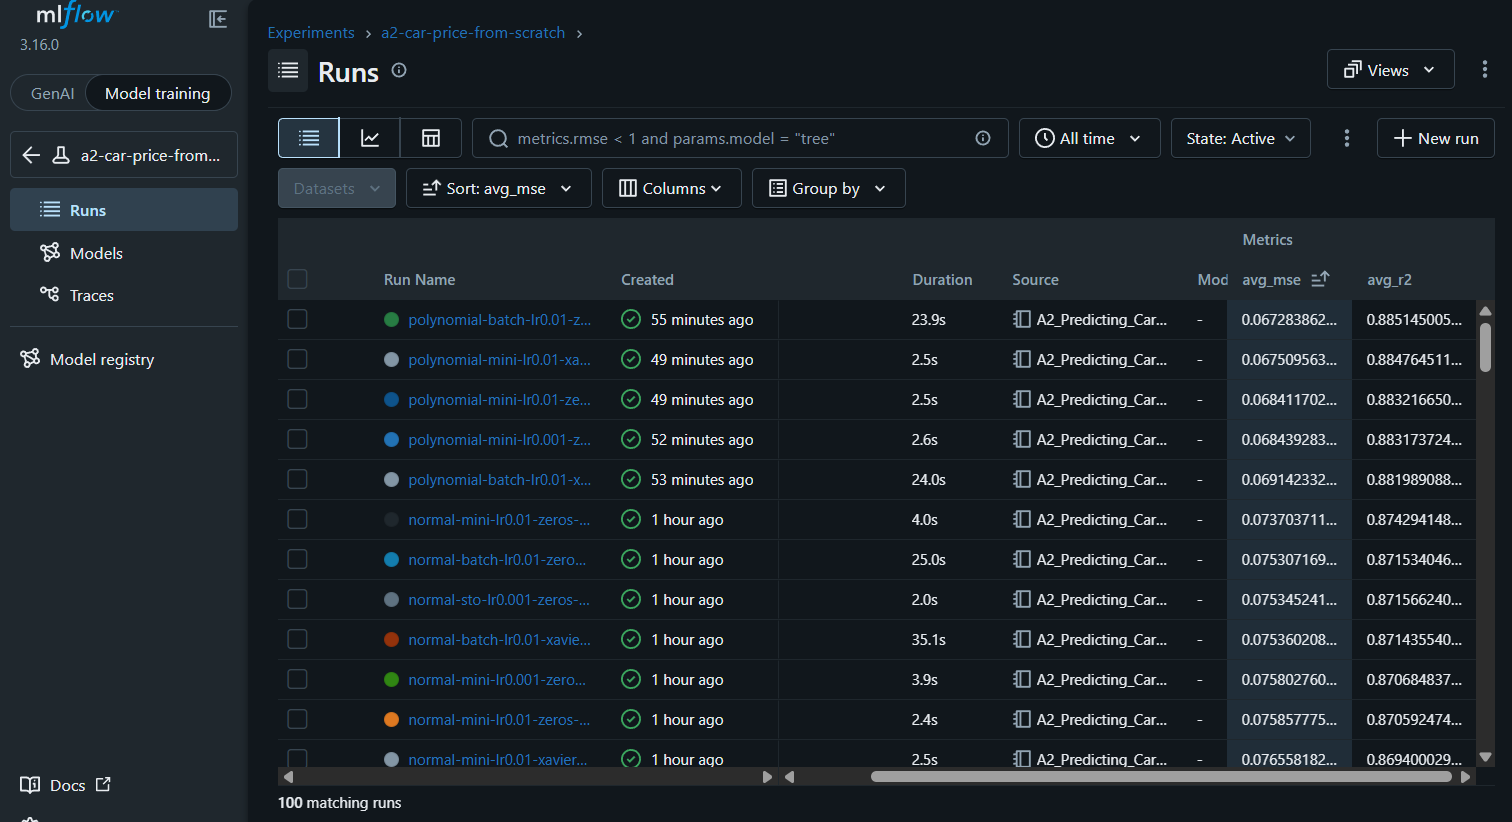

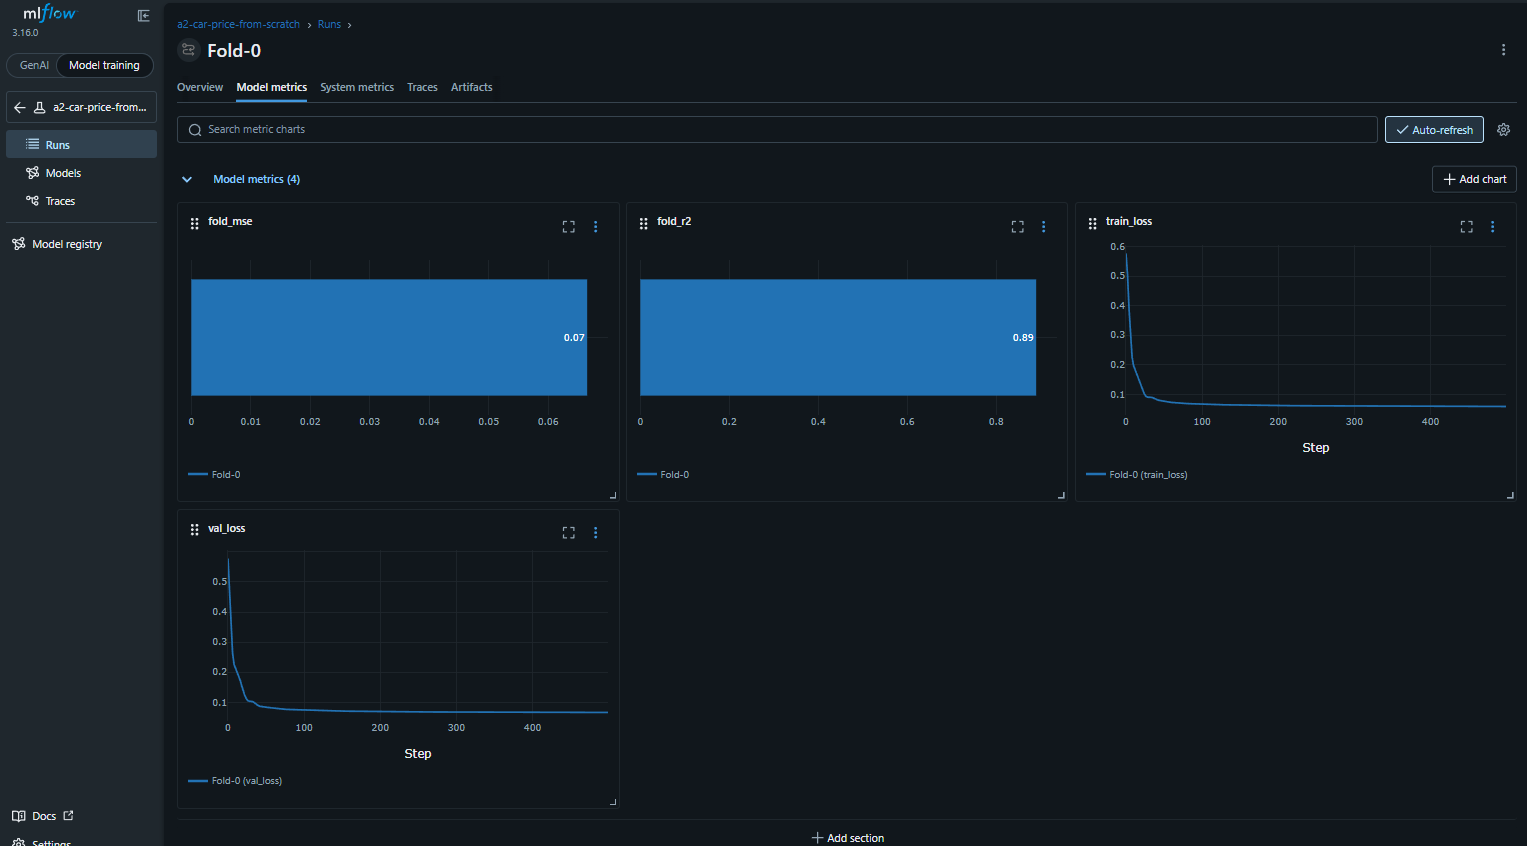

In [82]:
import os
print("notebook cwd:", os.getcwd())
print("tracking uri:", mlflow.get_tracking_uri())

notebook cwd: d:\AIT SEM 2\ML\ML_Assignment\A2
tracking uri: sqlite:///D:/AIT%20SEM%202/ML/ML_Assignment/A2/mlflow.db


## Deployment

The site runs on the ml-brain server at web-st126686.ml.brain.cs.ait.ac.th, served by a
Docker container behind Traefik as a reverse proxy. Both models are available, the old
Random Forest from A1 and the new model built here.

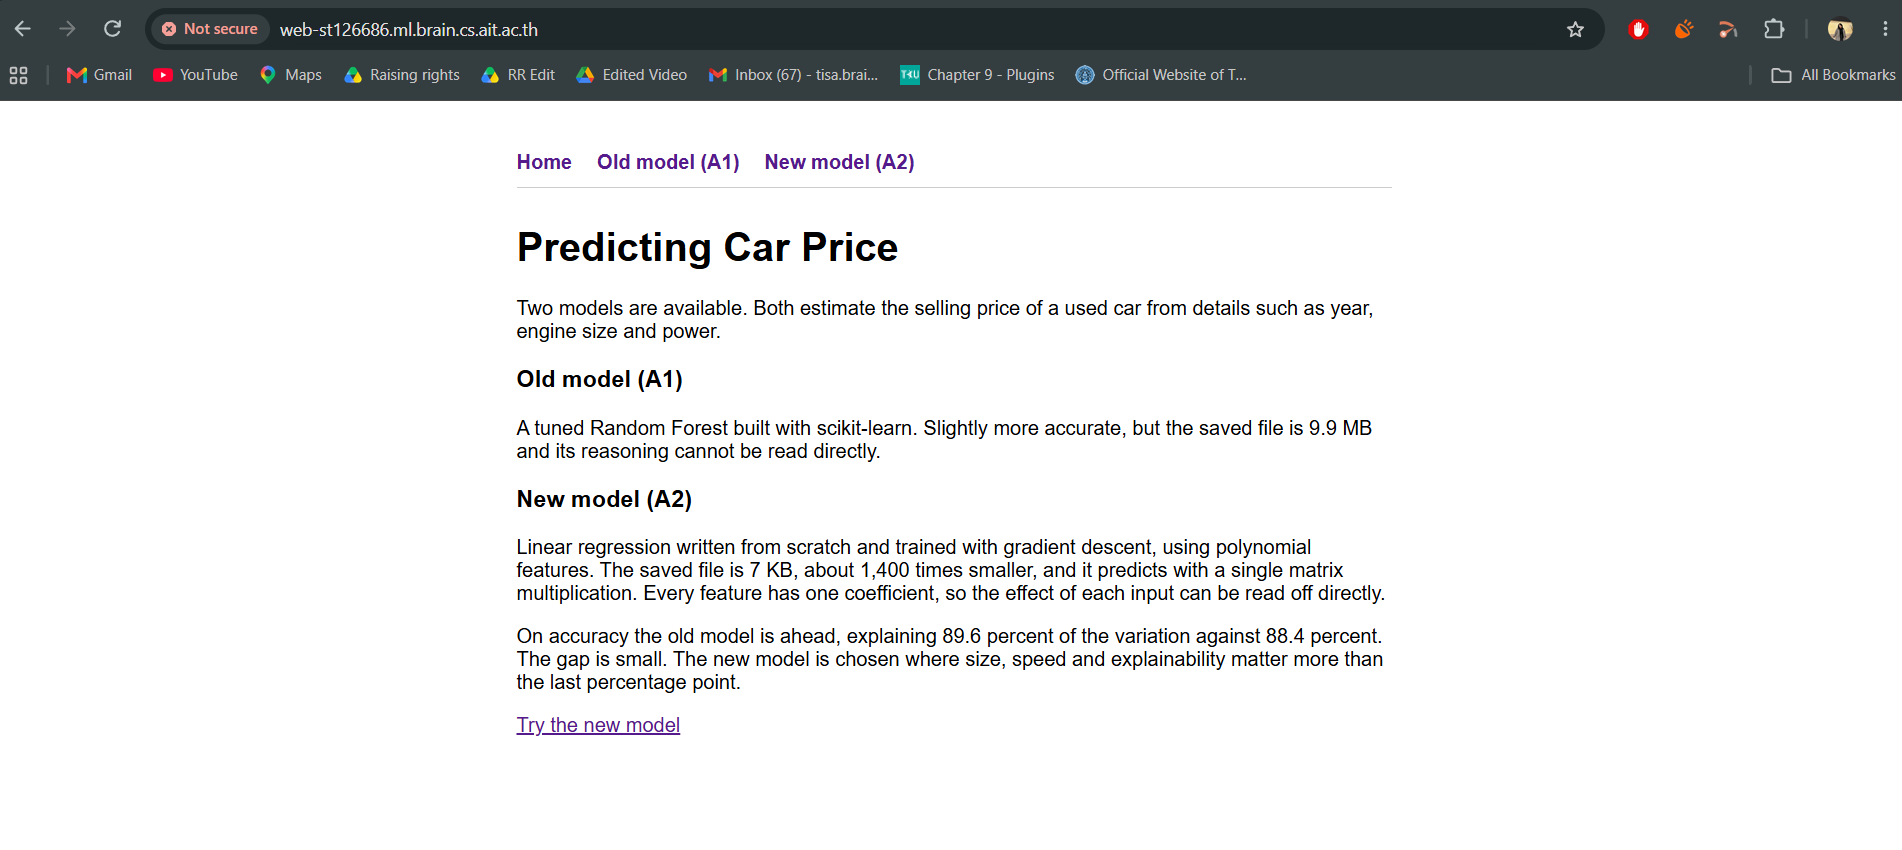

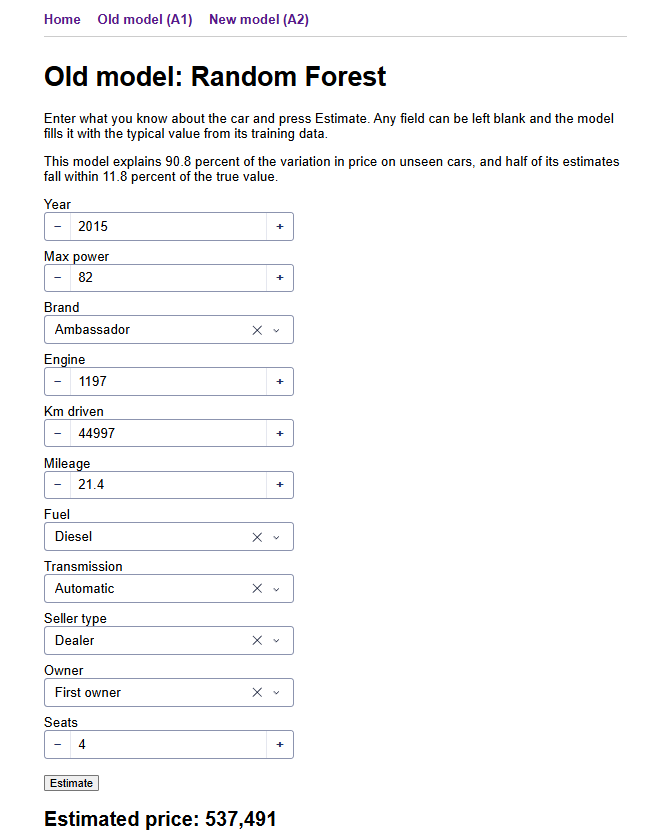

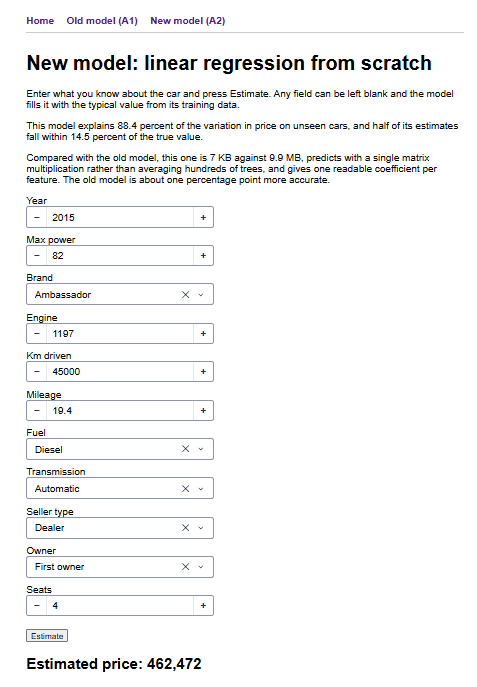

### Comparing the two models on one car

The same car submitted to both pages gives 537,491 from the Random Forest and 462,472 from
the new model, a difference of about 14 percent. Both scores sit close on average, 88.4
percent of variance explained against 90.8, but on any single car they can disagree by more
than either model's typical error.

The reason is in how each one handles a rare combination. This car is an Ambassador, a brand
with very few rows in the training data, with an automatic transmission and a diesel engine.
A forest can isolate such a group in its own leaf and price it separately. A linear model
applies one coefficient per feature and adds them up, so an unusual combination gets the sum
of its parts rather than a price of its own. Only the pairwise terms among the numeric
columns allow any interaction at all, and brand is not one of them.

The gap is not evidence that one answer is wrong. It shows that an average score hides how
much two models can differ on an individual prediction, which matters for a site quoting a
price to one person at a time.

# Task 3: Deployment

The Dash application was containerized with Docker and deployed on the AIT ML server.
The steps below describe the process.

## Step 1: Build and push the Docker image

The image was built locally and pushed to Docker Hub under tisa99/a2-predicting-car-price.
The image is 174 MB and contains both models, so one container serves both pages.

    docker compose build
    docker push tisa99/a2-predicting-car-price:latest

## Step 2: Configure SSH access

The ML server is reached through the bazooka jump host. Adding this to ~/.ssh/config avoids
retyping the full command each time.

    Host bazooka
        HostName bazooka.cs.ait.ac.th
        User st126686
        IdentityFile ~/.ssh/id_ed25519

    Host mlserver
        HostName ml.brain.cs.ait.ac.th
        User st126686
        IdentityFile ~/.ssh/id_ed25519
        ProxyJump bazooka

The hostname is used rather than the IP address given in the brief. That address,
192.41.170.25, does not respond to ping or accept connections on port 22. The server
resolves to 192.41.170.105.

## Step 3: Connect to the ML server

    ssh mlserver

The connection passes through bazooka, which asks for the CSIM password. The private key
then authenticates on the second hop, giving the prompt:

    st126686@ml-brain:~$

## Step 4: Check the existing containers

    docker ps

This lists every container on the shared server, including Traefik and other students'
deployments. Traefik holds ports 80 and 443. Every application container exposes only an
internal port with no host mapping.

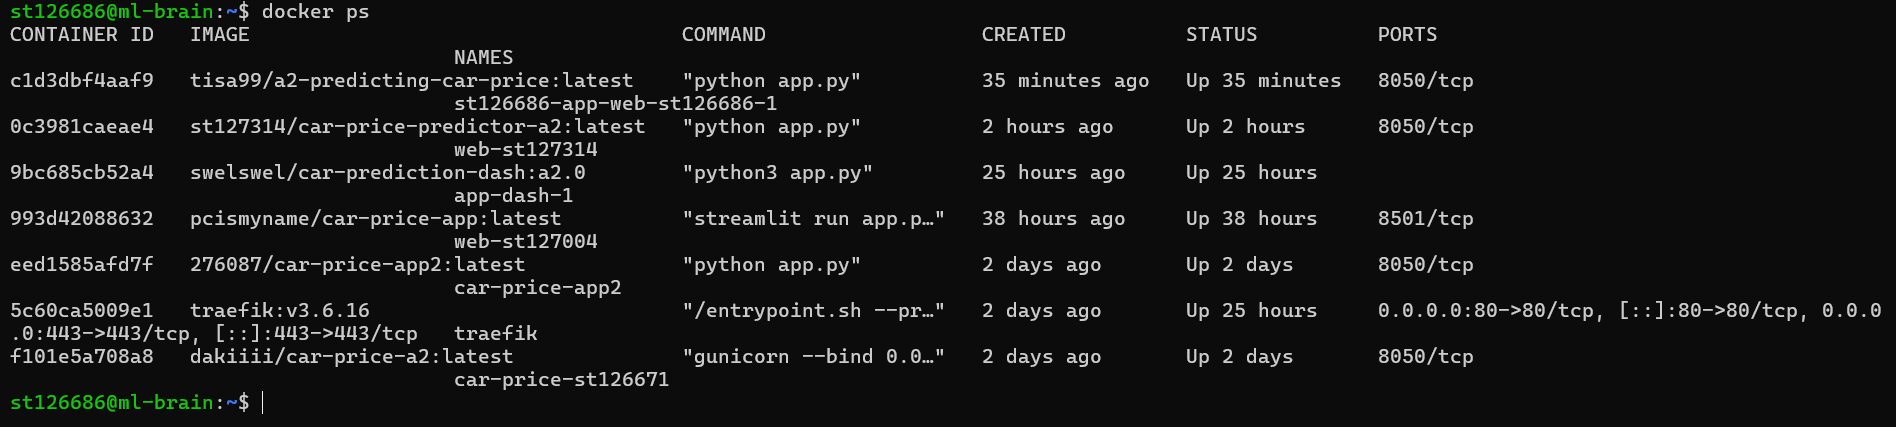

## Step 5: Write the compose file

    mkdir -p ~/st126686-app
    cd ~/st126686-app

The compose file pulls the image rather than building it, since there is no source code on
the server.

    services:
      web-st126686:
        image: tisa99/a2-predicting-car-price:latest
        restart: unless-stopped

        labels:
          - traefik.enable=true
          - traefik.http.routers.web-st126686.rule=Host(`web-st126686.ml.brain.cs.ait.ac.th`)
          - traefik.http.routers.web-st126686.entrypoints=websecure
          - traefik.http.routers.web-st126686.tls=true
          - traefik.http.routers.web-st126686.tls.certresolver=letsencrypt
          - traefik.http.services.web-st126686.loadbalancer.server.port=8050

        networks:
          - web

    networks:
      web:
        external: true

Three settings differ from the template provided with the assignment. The certificate
resolver is letsencrypt, not production. The network is web, not traefik_default. And the
container is attached to the web network only.

## Step 6: Start the container

    docker compose up -d
    docker ps | grep st126686

The container shows port 8050 internal and no host mapping, which is correct. Traefik
shares the web network and reaches the container directly at that port.

## Step 7: Verify the routing

    curl -sk -H "Host: web-st126686.ml.brain.cs.ait.ac.th" https://localhost/

A response code of 200 confirms Traefik is matching the Host rule and forwarding to the
container. This test bypasses DNS, so it isolates routing from name resolution.

## Step 8: Access the deployed application

    https://web-st126686.ml.brain.cs.ait.ac.th

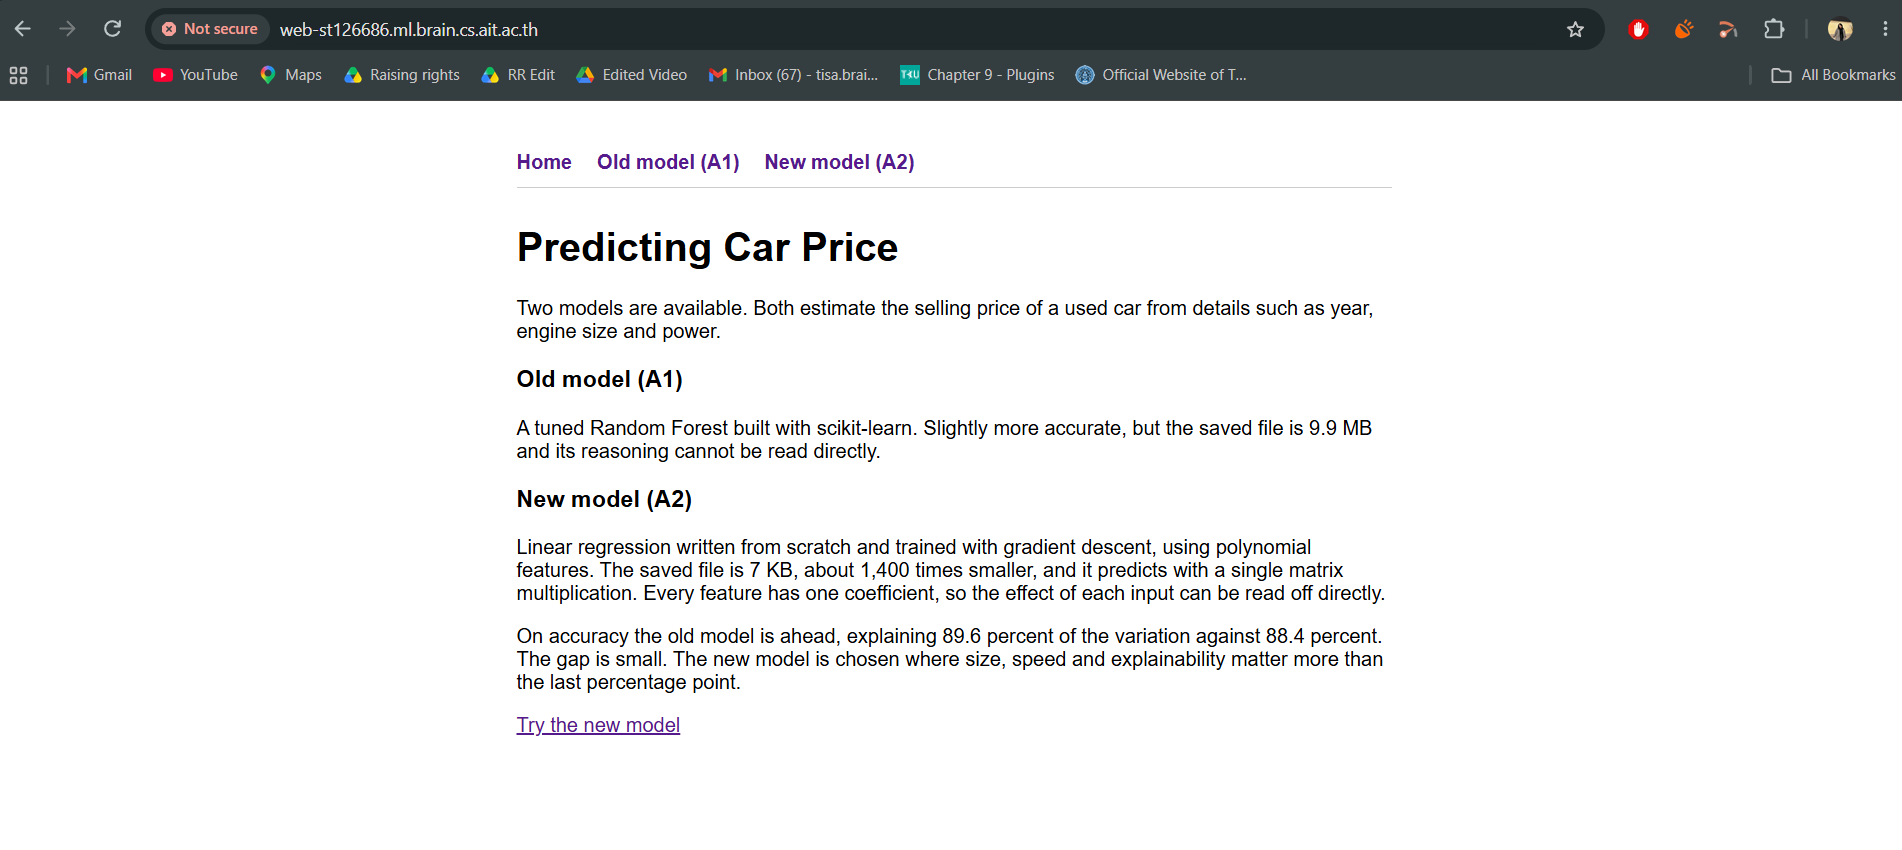